# Лабораторная работа №6. Методы агрегирования многомерных марковских процессов
Группа: ИУ5-81Б

№ по списку: 20

## Задание

$K$ программистов могут писать программы для выполнения на одном из $M$ серверов, при этом программа не попадает сразу на сервер, а обрабатывается на одном из $N$ специальных компьютеров, которые проверяют отсутствие вирусов. Интенсивность работы программистов $\lambda$, интенсивность работы компьютеров-антивирусов $\nu$, интенсивность работы основных серверов $\mu$, программа оказывается с вирусом с вероятностью $p$. Если программа с вирусом, она получает отказ обслуживания на основных серверах. Для компьютеров по проверке вирусов имеется ограничение по длине очереди $m_1$, для основных серверов ограничение по длине очереди $m_2$.

- Нарисовать граф состояний системы, учитывая количество программистов, которые пишут программу, количество программ на компьютерах-антивирусах, количество программ на серверах;
- Написать уравнения Колмогорова для вероятностей состояний, финальных вероятностей;
- Тремя способами (экспериментально с использованием пакета simmer, методом на основе параметров связи, теоретически по уравнениям Колмогорова) найти основные характеристики эффективности СМО: среднее время пребывания заявки в системе, абсолютную пропускную способность, среднее число заявок в системе.
- методом укрупнения состояний выполнить горизонтальное укрупнение, вертикальное укрупнение, сравнить полученные стационарные вероятности укрупненных состояний с вероятностями, полученным теоретически.
- исследовать, при каких значениях $m_1, m_2$  обеспечивается минимальное время пребывания заявки в системе с сохранением на заданном уровне абсолютной пропускной способности.

In [3]:
Variant<-20
set.seed(Variant+864)
K<-sample(c(4:8),1)
M<-sample(c(2:5),1)
N<-sample(c(2:6),1)
lambda<-runif(1)
mu<-runif(1)
nu<-runif(1)
p<-runif(1,0,0.5)
m1<-sample(c(1:3),1)
m2<-sample(c(1:3),1)
View(data.frame(K,M,N,lambda,mu,nu,p,m1,m2))

K,M,N,lambda,mu,nu,p,m1,m2
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
8,4,2,0.8026592,0.9034877,0.9562777,0.2955269,2,3


## Решение

Вспомним **параметры 20 варианта**:
*   Всего программ/программистов в замкнутой системе: **$K = 8$**
*   Максимальная вместимость блока Антивирусов: **$N + m_1 = 2 + 2 = 4$ заявки** (2 проверяются + 2 в очереди)
*   Максимальная вместимость блока Серверов: **$M + m_2 = 4 + 3 = 7$ заявок** (4 исполняются + 3 в очереди)

Чтобы не путаться в пяти переменных $(k, n, q_1, m, q_2)$, давайте объединим их в логические блоки:
Пусть **$X$** — общее число заявок в блоке Антивирусов ($X = n + q_1$).
Пусть **$Y$** — общее число заявок в блоке Серверов ($Y = m + q_2$).

Мы знаем, что система замкнутая, значит общее количество заявок всегда равно 8:
$k + X + Y = 8$

Так как количество работающих программистов $k$ не может быть отрицательным ($k \ge 0$), из этого следует главное ограничение:
**$X + Y \le 8$**

Теперь давайте просто переберем все возможные комбинации $X$ и $Y$, помня о том, что $X$ не может быть больше 4, $Y$ не может быть больше 7, а их сумма не может быть больше 8.

*   Если в Антивирусах **$X = 0$** заявок: в Серверах $Y$ может быть от 0 до 7 $\rightarrow$ **8 состояний**
*   Если в Антивирусах **$X = 1$** заявка: в Серверах $Y$ может быть от 0 до 7 $\rightarrow$ **8 состояний**
*   Если в Антивирусах **$X = 2$** заявки: в Серверах $Y$ может быть от 0 до 6 (т.к. 2+6=8) $\rightarrow$ **7 состояний**
*   Если в Антивирусах **$X = 3$** заявки: в Серверах $Y$ может быть от 0 до 5 (т.к. 3+5=8) $\rightarrow$ **6 состояний**
*   Если в Антивирусах **$X = 4$** заявки (это максимум для этого блока): в Серверах $Y$ может быть от 0 до 4 (т.к. 4+4=8) $\rightarrow$ **5 состояний**

**Считаем сумму:**
8 + 8 + 7 + 6 + 5 = **34 состояния ровно**.

*(Примечание: зная только $X$ и $Y$, мы однозначно восстанавливаем полные состояния. Например, если $X=3$, мы точно знаем, что $n=2, q_1=1$, потому что сначала заполняются все 2 антивирусных компьютера, а только потом 1 заявка встает в очередь. Аналогично для $Y$.)*

[1] TRUE

Успешно сгенерировано состояний: 34 


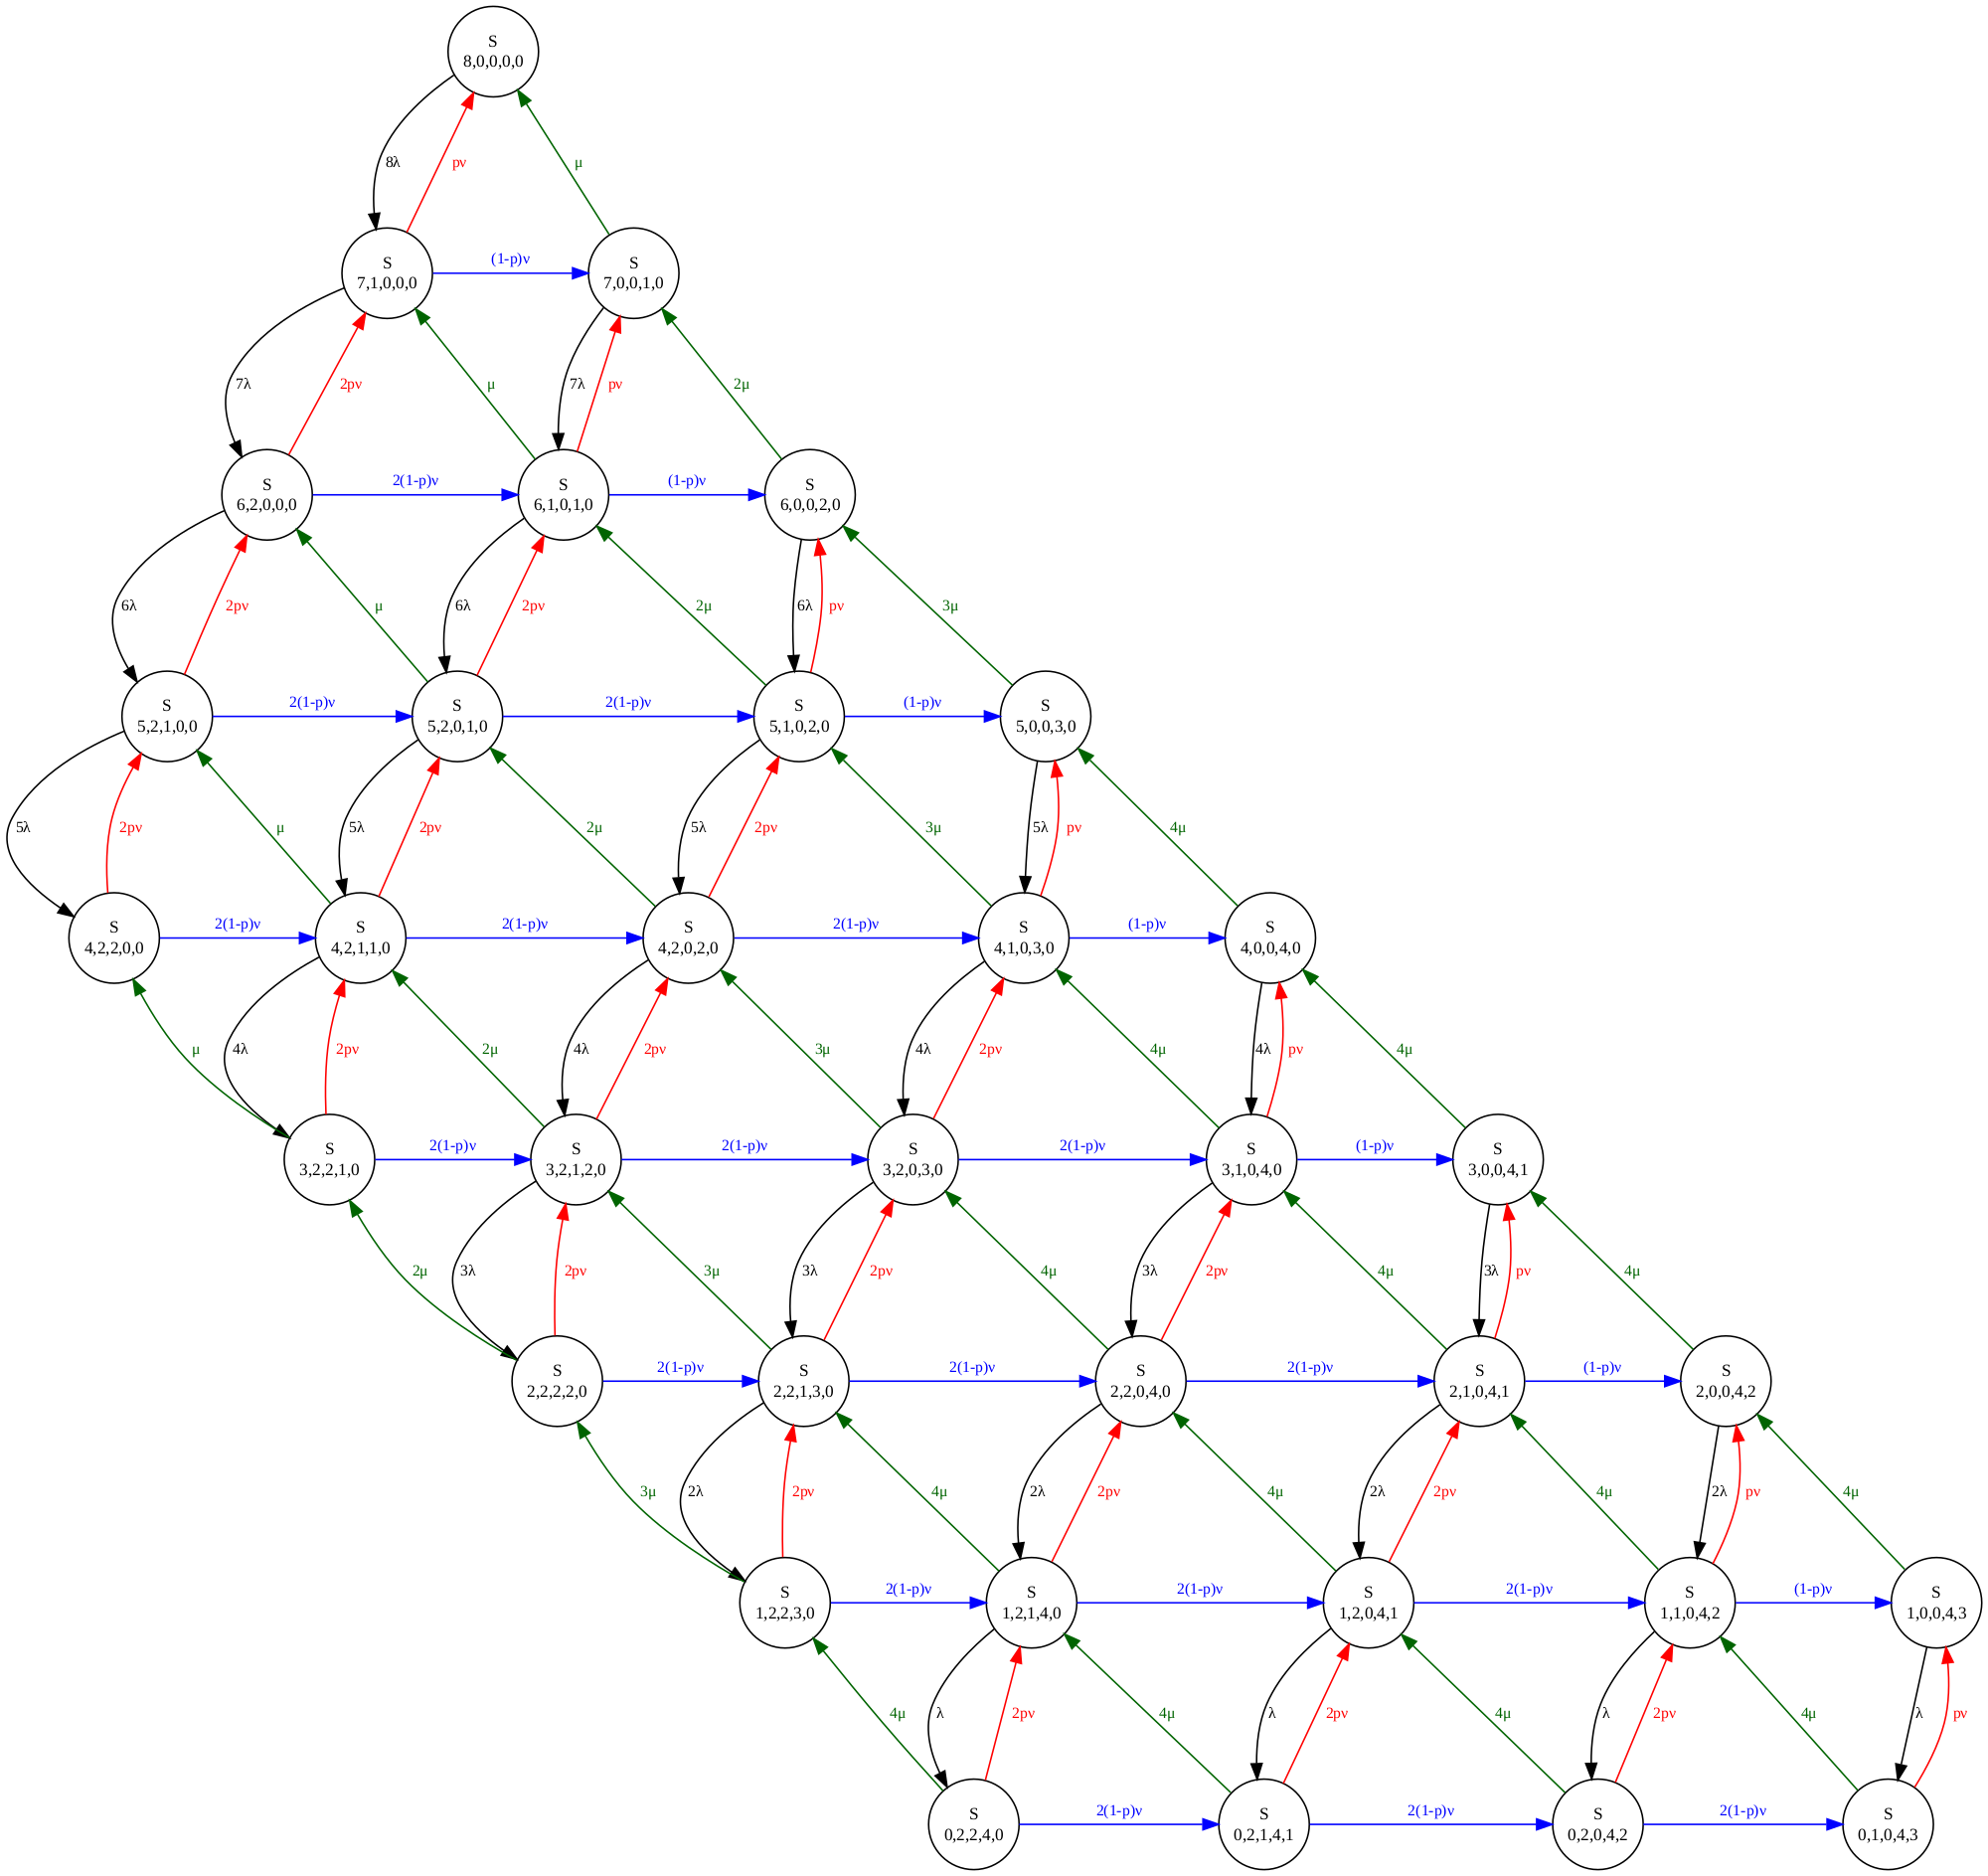

In [15]:
# Устанавливаем необходимые системные пакеты
system("apt-get update -qq")
system("apt-get install -y librsvg2-dev")

# Устанавливаем необходимые R-пакеты
if (!require("DiagrammeR")) install.packages("DiagrammeR")
if (!require("DiagrammeRsvg")) install.packages("DiagrammeRsvg")
if (!require("rsvg")) install.packages("rsvg")
if (!require("IRdisplay")) install.packages("IRdisplay")

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# --- Параметры варианта 20 ---
K <- 8
N <- 2
M <- 4
m1 <- 2
m2 <- 3

states <- list()
edges_list <- list() # This will be the final list of edges

# Функция добавления состояния
add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name)
    return(TRUE)
  }
  return(FALSE)
}

# Инициализация (все программисты пишут код)
queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)

# Генерация состояний
head <- 1
temp_edges_list <- list() # Temporary list to collect edges within the loop

while(head <= length(queue)) {
  curr <- queue[[head]]
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  head <- head + 1

  tot_AV <- n + q1
  tot_MS <- m + q2

  # 1. Программист написал код
  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n)
    nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    rate <- ifelse(k > 1, paste0(k, "λ"), "λ")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }

  # 2. Антивирус нашел вирус (возврат к программисту)
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1)
    nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    rate <- ifelse(n > 1, paste0(n, "pν"), "pν")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }

  # 3. Антивирус пропустил код на сервер
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1)
    nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m)
    nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    rate <- ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="blue", fontcolor="blue"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), rate)
  }

  # 4. Сервер выполнил программу (возврат к программисту)
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1)
    nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    rate <- ifelse(m > 1, paste0(m, "μ"), "μ")
    temp_edges_list[[length(temp_edges_list)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), rate)
  }
}

edges_list <- temp_edges_list # Assign the collected edges to the global variable

# --- ГРУППИРОВКА ПО УРОВНЯМ ДЛЯ КРАСИВОГО ГРАФА ---
nodes_by_k <- list()
for (name in names(states)) {
  k_val <- as.character(states[[name]]$k)
  if (is.null(nodes_by_k[[k_val]])) nodes_by_k[[k_val]] <- c()
  nodes_by_k[[k_val]] <- c(nodes_by_k[[k_val]], sprintf('"%s" [label="%s"];', states[[name]]$name, states[[name]]$label))
}

graph_str <- "digraph G {\n  layout=dot;\n  rankdir=TB;\n  nodesep=0.7;\n  ranksep=1.0;\n  splines=true;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=11, style=filled, fillcolor=white];\n  edge [fontsize=10];\n"

# Принудительно выстраиваем состояния по уровням 'k'
for (k_val in sort(as.numeric(names(nodes_by_k)), decreasing = TRUE)) {
  graph_str <- paste0(graph_str, "  { rank=same;\n")
  graph_str <- paste0(graph_str, paste(nodes_by_k[[as.character(k_val)]], collapse="\n    "), "\n")
  graph_str <- paste0(graph_str, "  }\n")
}

graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

# --- Экспорт и отображение ---
g <- grViz(graph_str)
svg_code <- export_svg(g)
writeLines(svg_code, "graph.svg")
rsvg_png(charToRaw(svg_code), "graph.png", width = 2000)

cat("Успешно сгенерировано состояний:", length(states), "\n")
display_png(file="graph.png")

### Уравнения Колмогорова

#### Уравнения Колмогорова для вероятностей состояний

В связи с большой размерностью системы (34 возможных состояния для $K = 8$), полная запись системы дифференциальных уравнений Колмогорова является громоздкой. Запишем общее правило формирования уравнений: производная вероятности нахождения системы в $i$-ом состоянии равна сумме потоков вероятностей, переводящих систему в это состояние (входящие потоки), минус сумма потоков вероятностей, выводящих систему из этого состояния (исходящие потоки).

Для примера составим уравнения Колмогорова для первых нескольких (верхних) состояний графа:

**1. Для состояния $S_{8,0,0,0,0}$ (все 8 программистов пишут код):** В это состояние система может перейти, если антивирус найдет вирус в $S_{7,1,0,0,0}$ (интенсивность $p\nu$), либо если сервер закончит обработку программы из $S_{7,0,0,1,0}$ (интенсивность $\mu$). Выходит система из этого состояния, когда любой из 8 программистов дописывает код (интенсивность $8\lambda$).
$$ \frac{dP_{80000}(t)}{dt} = -8\lambda P_{80000}(t) + p\nu P_{71000}(t) + \mu P_{70010}(t) $$

**2. Для состояния $S_{7,1,0,0,0}$ (7 пишут, 1 проверяется на вирусы):**
$$ \frac{dP_{71000}(t)}{dt} = 8\lambda P_{80000}(t) + 2p\nu P_{62000}(t) + \mu P_{61010}(t) - (7\lambda + p\nu + (1 - p)\nu)P_{71000}(t) $$
*Примечание: $(p\nu + (1 - p)\nu) = \nu$, так как антивирус в любом случае завершает проверку.*

**3. Для состояния $S_{7,0,0,1,0}$ (7 пишут, 1 исполняется на сервере):**
$$ \frac{dP_{70010}(t)}{dt} = (1 - p)\nu P_{71000}(t) + p\nu P_{61010}(t) + 2\mu P_{60020}(t) - (7\lambda + \mu)P_{70010}(t) $$

И так далее для всех 34 состояний.

#### Финальные (стационарные) вероятности

Для нахождения финальных (стационарных) вероятностей, при $t \to \infty$, производные приравниваются к нулю: $\frac{dP_i(t)}{dt} = 0$.

Система алгебраических уравнений для стационарных вероятностей имеет вид:
$$ P \cdot Q = 0 $$
где $P = [P_1, P_2, \dots, P_{34}]$ — вектор стационарных вероятностей, а $Q$ — матрица интенсивностей переходов (инфинитезимальная матрица).

Для получения однозначного решения одно из уравнений системы заменяется нормировочным условием:
$$ \sum_{i=1}^{34} P_i = 1 $$

### Уравнение нормировки

Сумма вероятностей нахождения системы во всех 34 возможных состояниях всегда равна единице. Математически это записывается через сумму по всему пространству состояний $S$:
$$ \sum_{(k,n,q_1,m,q_2) \in S} P_{k,n,q_1,m,q_2} = 1 $$

В развернутом виде:
$$ P_{80000} + P_{71000} + P_{70010} + P_{62000} + \dots + P_{01043} = 1 $$
*(Примечание: $P_{01043}$ — один из вариантов крайнего состояния, когда все 8 заявок находятся в системе обслуживания: 1 на антивирусе, 4 на серверах и 3 в очереди к серверам).*

Для нахождения финальных (стационарных) вероятностей при $t \to \infty$ положим левую часть дифференциальных уравнений Колмогорова равной нулю (так как система приходит в равновесие, вероятности состояний перестают меняться, и их производные равны нулю).

В связи с большой размерностью системы (34 состояния), выпишем систему алгебраических уравнений для первых нескольких узлов графа:

$$
\begin{cases}
0 = -8\lambda P_{80000} + p\nu P_{71000} + \mu P_{70010} \\
0 = 8\lambda P_{80000} + 2p\nu P_{62000} + \mu P_{61010} - (7\lambda + \nu)P_{71000} \\
0 = (1 - p)\nu P_{71000} + p\nu P_{61010} + 2\mu P_{60020} - (7\lambda + \mu)P_{70010} \\
0 = 7\lambda P_{71000} + 2p\nu P_{52100} + \mu P_{52010} - (6\lambda + 2\nu)P_{62000} \\
\dots \\
\text{(и так далее для всех 34 состояний)}
\end{cases}
$$

*(Примечание к 4-му уравнению: интенсивность обнаружения вируса из состояния $P_{52100}$ равна $2p\nu$, а не $3p\nu$, так как всего антивирусных компьютеров $N=2$, и третья заявка находится в очереди $q_1=1$ и не обрабатывается).*

*(Примечание: для компактности записи учтено, что $p\nu + (1 - p)\nu = \nu$)*

Полная система состоит из 34 линейных алгебраических уравнений. Решать её аналитически (вручную методом подстановки) нецелесообразно. Для нахождения численных значений стационарных вероятностей мы сформируем инфинитезимальную матрицу переходов программно и решим СЛАУ матричным методом. Одно из уравнений системы при решении будет заменено нормировочным условием $\sum P_i = 1$.

### Основные характеристики СМО

#### Теоретически по уравнениям Колмогорова

In [ ]:
install.packages("rim")
library(rim)

Устанавливаю пакет в ‘/opt/homebrew/lib/R/4.5/site-library’
(потому что ‘lib’ не определено)





                 _____                        
                |  ___| __ ___  ___           
                | |_ | '__/ _ \/ _ \          
                |  _|| | |  __/  __/          
      ____      |_|  |_|  \___|\___|          
     |  _ \ __ _| | ___  ___| |_(_)_ __   ___ 
     | |_) / _` | |/ _ \/ __| __| | '_ \ / _ \
     |  __/ (_| | |  __/\__ \ |_| | | | |  __/
     |_|   \__,_|_|\___||___/\__|_|_| |_|\___|




Maxima successfully registered as knitr engine!



In [ ]:
maxima.isInstalled()

[1] TRUE

In [16]:
# --- Параметры варианта 20 ---
K <- 8
M <- 4
N <- 2
lambda <- 0.8026592
mu <- 0.9034877
nu <- 0.9562777
p <- 0.2955269
m1 <- 2
m2 <- 3

# 1. Генерируем список состояний
states <- list()
add_state <- function(k, n, q1, m, q2) {
  name <- paste0("P_", k, "_", n, "_", q1, "_", m, "_", q2)
  if (!(name %in% names(states))) {
    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, name=name)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1
while(head <= length(queue)) {
  curr <- queue[[head]]
  head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]

  tot_AV <- n + q1
  tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
  }
}

state_names <- names(states)
num_states <- length(state_names)

# 2. Создаем и заполняем матрицу переходов Q (размер 34x34)
Q <- matrix(0, nrow=num_states, ncol=num_states)
rownames(Q) <- state_names
colnames(Q) <- state_names

get_idx <- function(name) which(state_names == name)

for (name in state_names) {
  curr <- states[[name]]
  k <- curr$k; n <- curr$n; q1 <- curr$q1; m <- curr$m; q2 <- curr$q2
  tot_AV <- n + q1
  tot_MS <- m + q2
  i <- get_idx(name)

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    next_name <- paste0("P_", k-1, "_", nn, "_", nq1, "_", m, "_", q2)
    Q[i, get_idx(next_name)] <- k * lambda
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    next_name <- paste0("P_", k+1, "_", nn, "_", nq1, "_", m, "_", q2)
    Q[i, get_idx(next_name)] <- n * p * nu
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    next_name <- paste0("P_", k, "_", nn, "_", nq1, "_", nm, "_", nq2)
    Q[i, get_idx(next_name)] <- n * (1-p) * nu
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    next_name <- paste0("P_", k+1, "_", n, "_", q1, "_", nm, "_", nq2)
    Q[i, get_idx(next_name)] <- m * mu
  }
}

for(i in 1:num_states) Q[i,i] <- -sum(Q[i, -i])

# 3. Решаем систему
A <- t(Q)
b <- rep(0, num_states)
A[num_states, ] <- 1
b[num_states] <- 1

probabilities <- solve(A, b)

# Сохраняем вероятности в удобный список для следующих расчетов
P <- list()
for (i in 1:num_states) {
  P[[state_names[i]]] <- probabilities[i]
}

cat("Система из", num_states, "уравнений успешно решена!\n")
cat("Сумма вероятностей:", sum(probabilities), "(если 1, то всё верно)\n")

[1] TRUE

Система из 34 уравнений успешно решена!
Сумма вероятностей: 1 (если 1, то всё верно)


In [17]:
# --- Расчет теоретических характеристик эффективности СМО ---

# 1. Среднее число работающих программистов (заявок, которые еще не поступили в СМО)
K_avg <- 0
for (name in names(states)) {
  K_avg <- K_avg + states[[name]]$k * P[[name]]
}

# 2. Среднее число заявок внутри системы (в очередях и на обслуживании)
# Так как система замкнутая (всего K программистов), то:
L_sys <- K - K_avg

# 3. Абсолютная пропускная способность (A)
# Это среднее число заявок, успешно выполненных серверами в единицу времени.
# Заявка покидает СМО и возвращается программисту, когда основной сервер заканчивает работу.
# Интенсивность этого потока в каждом состоянии равна (m * mu)
A <- 0
for (name in names(states)) {
  A <- A + states[[name]]$m * mu * P[[name]]
}

# 4. Среднее время пребывания заявки в системе (W)
# Применяем закон Литтла для замкнутых систем: L_sys = A * W => W = L_sys / A
W <- L_sys / A

# Красивый вывод результатов
cat("--- ТЕОРЕТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ЭФФЕКТИВНОСТИ СМО ---\n")
cat("1. Среднее число заявок в системе (L_sys):", round(L_sys, 4), "\n")
cat("2. Абсолютная пропускная способность (A):", round(A, 4), "заявок в ед. времени\n")
cat("3. Среднее время пребывания заявки в системе (W):", round(W, 4), "ед. времени\n")

--- ТЕОРЕТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ЭФФЕКТИВНОСТИ СМО ---
1. Среднее число заявок в системе (L_sys): 4.4159 
2. Абсолютная пропускная способность (A): 1.2573 заявок в ед. времени
3. Среднее время пребывания заявки в системе (W): 3.5122 ед. времени


### Метод укрупнения состояний

[1] TRUE

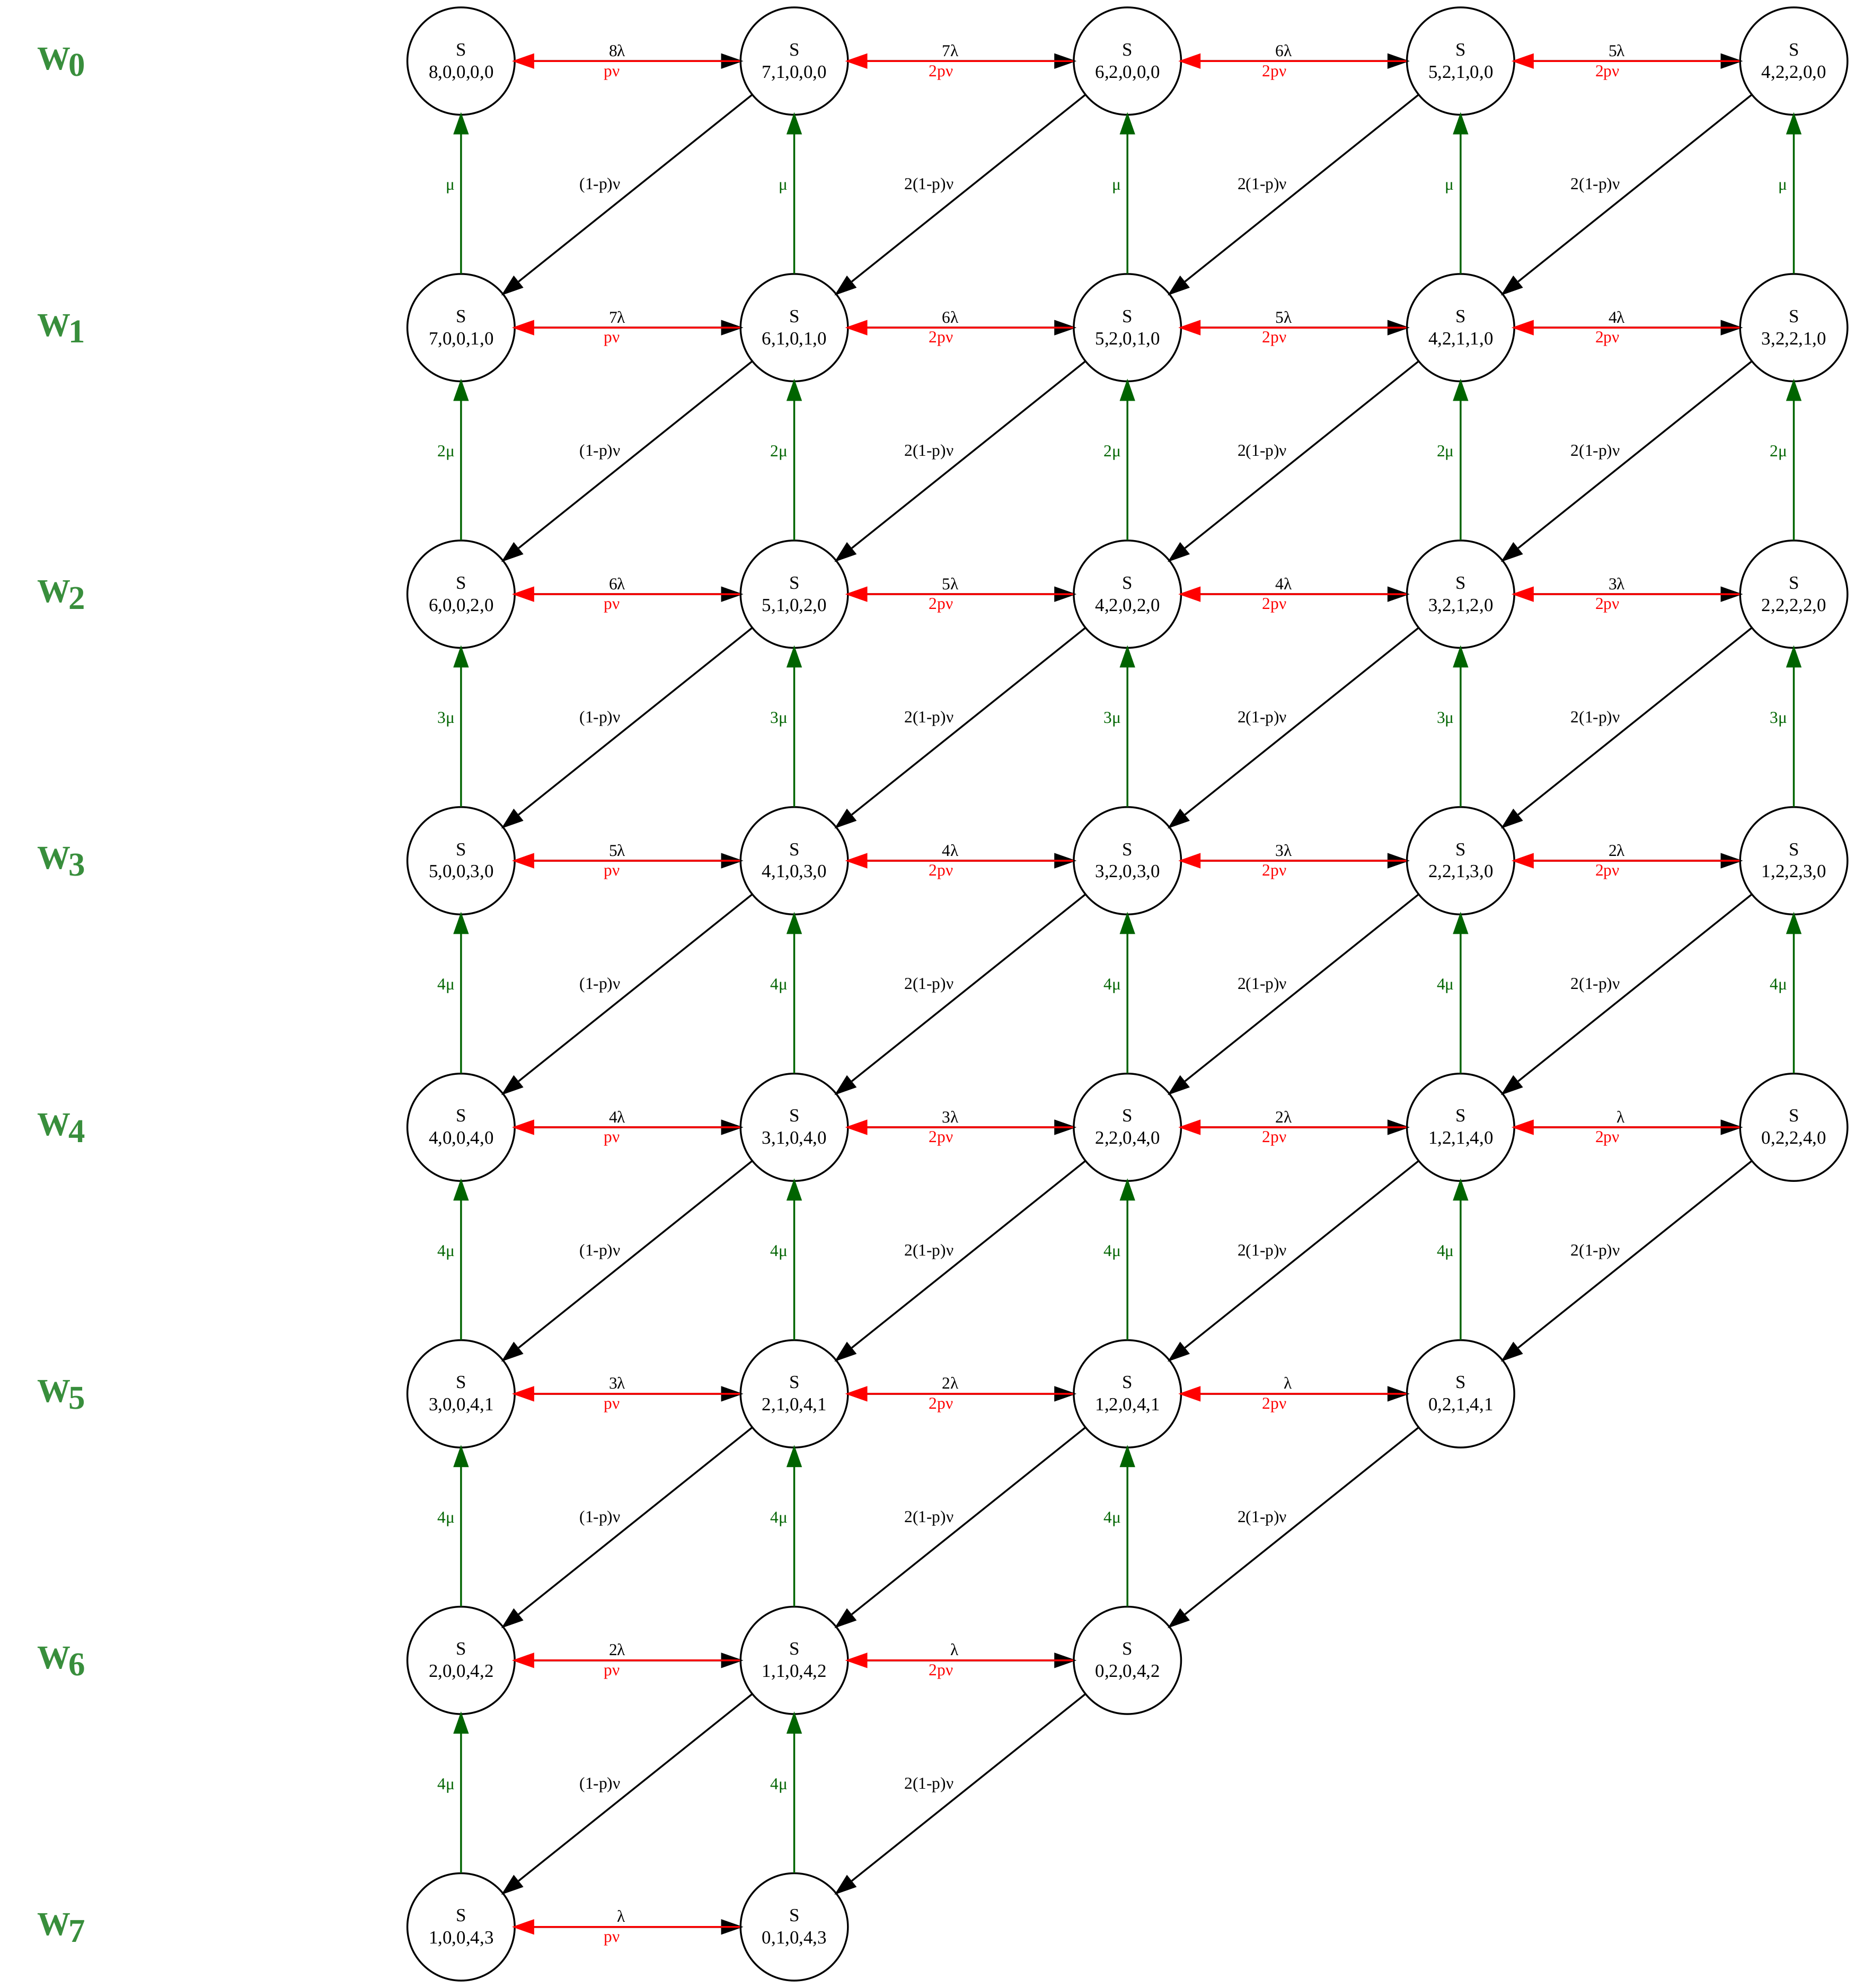



=============== for MARKDOWN output this  ===============
### Горизонтальное укрупнение

$$W_0 = \{ S_{80000}, S_{71000}, S_{62000}, S_{52100}, S_{42200} \}$$

$$W_1 = \{ S_{70010}, S_{61010}, S_{52010}, S_{42110}, S_{32210} \}$$

$$W_2 = \{ S_{60020}, S_{51020}, S_{42020}, S_{32120}, S_{22220} \}$$

$$W_3 = \{ S_{50030}, S_{41030}, S_{32030}, S_{22130}, S_{12230} \}$$

$$W_4 = \{ S_{40040}, S_{31040}, S_{22040}, S_{12140}, S_{02240} \}$$

$$W_5 = \{ S_{30041}, S_{21041}, S_{12041}, S_{02141} \}$$

$$W_6 = \{ S_{20042}, S_{11042}, S_{02042} \}$$

$$W_7 = \{ S_{10043}, S_{01043} \}$$



In [18]:
system("apt-get update -qq")
system("apt-get install -y librsvg2-dev")

# Устанавливаем пакеты, если вдруг они пропали
if (!require("DiagrammeR")) install.packages("DiagrammeR")
if (!require("DiagrammeRsvg")) install.packages("DiagrammeRsvg")
if (!require("rsvg")) install.packages("rsvg")
if (!require("IRdisplay")) install.packages("IRdisplay")

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)


K <- 8; N <- 2; M <- 4; m1 <- 2; m2 <- 3

states <- list()
edges_list_temp <- list() # Use a temporary list for edge collection

add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    # Рассчитываем координаты сетки
    # X зависит от загрузки антивируса, Y зависит от загрузки серверов
    v <- n + q1
    w <- m + q2
    x_pos <- v * 2.5
    y_pos <- -w * 2.0

    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name, v=v, w=w, x=x_pos, y=y_pos)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1

while(head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  tot_AV <- n + q1; tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    rate <- ifelse(k > 1, paste0(k, "λ"), "λ")
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    rate <- ifelse(n > 1, paste0(n, "pν"), "pν")
    # Добавляем искривление для обратной связи, чтобы стрелка не шла сквозь другие узлы
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), rate)
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    rate <- ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), rate)
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    rate <- ifelse(m > 1, paste0(m, "μ"), "μ")
    # Зеленая стрелка для успешного выполнения
    edges_list_temp[[length(edges_list_temp)+1]] <- sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), rate)
  }
}

edges_list <- edges_list_temp # Assign the collected edges to the main variable

# --- ФОРМИРОВАНИЕ ГРАФА ---
# Используем neato и сплайны для аккуратного огибания узлов
graph_str <- "digraph G {\n  layout=neato;\n  splines=true;\n  overlap=false;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=10, style=filled, fillcolor=white];\n  edge [fontsize=9];\n"

# 1. Рисуем узлы по заданным координатам pos="x,y!" (знак ! запрещает программе их двигать)
for (name in names(states)) {
  s <- states[[name]]
  graph_str <- paste0(graph_str, sprintf('  "%s" [label="%s", pos="%f,%f!"];\n', name, s$label, s$x, s$y))
}

# 2. Рисуем левые подписи W_0, W_1 ... для визуализации горизонтального укрупнения
clusters_list <- list()
for (w in 0:(M+m2)) {
  nodes_in_w <- names(states)[sapply(states, function(s) s$w == w)]
  if (length(nodes_in_w) > 0) {
    clusters_list[[as.character(w)]] <- nodes_in_w
    # Создаем прозрачный узел с текстом W слева от графа (X = -3)
    graph_str <- paste0(graph_str, sprintf('  "W_label_%d" [shape=none, label=<<font color="#388E3C" point-size="18"><b>W<SUB>%d</SUB></b></font>>, pos="-3.0,%f!"];\n', w, w, -w*2.0))
  }
}

# 3. Добавляем связи
graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

g <- grViz(graph_str)
svg_code <- export_svg(g)
rsvg_png(charToRaw(svg_code), "graph_grid.png", width = 3500)

display_png(file="graph_grid.png")

# --- ТЕКСТ ДЛЯ ОТЧЕТА ---
cat("\n\n=============== for MARKDOWN output this  ===============\n")
cat("### Горизонтальное укрупнение\n\n")

for (w in names(clusters_list)) {
  nodes <- clusters_list[[w]]
  formatted_nodes <- sapply(nodes, function(x) {
    parts <- strsplit(x, "_")[[1]]
    paste0("S_{", paste(parts[2:6], collapse=""), "}")
  })
  cat(paste0("$$W_", w, " = \\{ ", paste(formatted_nodes, collapse=", "), " \\}$$\n\n"))
}
cat("=======================================================================\n")

### Горизонтальное укрупнение

$$W_0 = \{ S_{80000}, S_{71000}, S_{62000}, S_{52100}, S_{42200} \}$$

$$W_1 = \{ S_{70010}, S_{61010}, S_{52010}, S_{42110}, S_{32210} \}$$

$$W_2 = \{ S_{60020}, S_{51020}, S_{42020}, S_{32120}, S_{22220} \}$$

$$W_3 = \{ S_{50030}, S_{41030}, S_{32030}, S_{22130}, S_{12230} \}$$

$$W_4 = \{ S_{40040}, S_{31040}, S_{22040}, S_{12140}, S_{02240} \}$$

$$W_5 = \{ S_{30041}, S_{21041}, S_{12041}, S_{02141} \}$$

$$W_6 = \{ S_{20042}, S_{11042}, S_{02042} \}$$

$$W_7 = \{ S_{10043}, S_{01043} \}$$


3. Граф макро-состояний W:


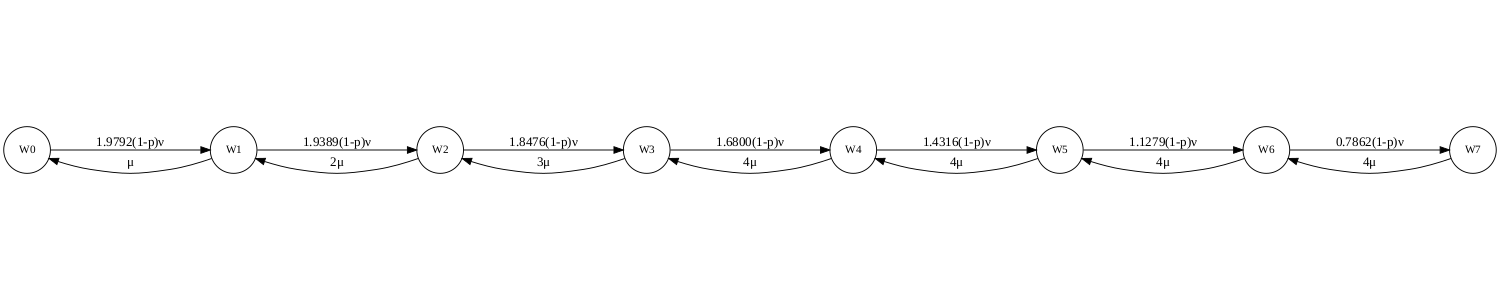

In [19]:
# 3. Рисуем граф макро-состояний
cat("3. Граф макро-состояний W:\n")

# --- PARAMETERS (ensuring consistency with P calculation and states generation) ---
# These values are taken from cell 5fd4ef6b-9a54-4cca-9124-32b3e2574c09 and P5h0CVQXgn1W
# --- Параметры варианта 20 ---
K <- 8
M <- 4
N <- 2
lambda <- 0.8026592
mu <- 0.9034877
nu <- 0.9562777
p <- 0.2955269
m1 <- 2
m2 <- 3

# --- Calculate P_W_exact (probabilities of horizontal macro-states W_w) ---
# `P` is from cell 5fd4ef6b-9a54-4cca-9124-32b3e2574c09
# `states` and `clusters_list` are from cell P5h0CVQXgn1W
P_W_exact <- rep(0, M + m2 + 1)
names(P_W_exact) <- paste0("W_", 0:(M+m2))

for (w_val_str in names(clusters_list)) {
  w_val <- as.numeric(w_val_str)
  for (s_name in clusters_list[[w_val_str]]) {
    # P is a list where keys are "P_k_n_q1_m_q2"
    # s_name from clusters_list is "S_k_n_q1_m_q2"
    # Need to convert s_name to match P's keys.
    if (gsub("^S_", "P_", s_name) %in% names(P)) { # Check if state exists in P
      P_W_exact[w_val + 1] <- P_W_exact[w_val + 1] + P[[gsub("^S_", "P_", s_name)]]
    }
  }
}

# --- Calculate 'z' as the effective number of active antivirus units for each W_w ---
# z[w] = (sum_{s in W_w} n_s * P_s) / P_W_w
z <- rep(0, M + m2 + 1) # Will store the average 'n' for each W_w
names(z) <- paste0("z_", 0:(M+m2))

for (w_val_str in names(clusters_list)) {
  w_val <- as.numeric(w_val_str)
  sum_n_P_s <- 0
  for (s_name in clusters_list[[w_val_str]]) {
    if (gsub("^S_", "P_", s_name) %in% names(P)) { # Check if state exists in P
      micro_state_k_n_q1_m_q2 <- states[[s_name]] # Get the full state definition
      sum_n_P_s <- sum_n_P_s + micro_state_k_n_q1_m_q2$n * P[[gsub("^S_", "P_", s_name)]]
    }
  }
  if (P_W_exact[w_val + 1] > 0) {
    z[w_val + 1] <- sum_n_P_s / P_W_exact[w_val + 1]
  } else {
    z[w_val + 1] <- 0 # If macro-state probability is zero, average n is also zero
  }
}

# --- Continue with graph generation using the calculated 'z' ---
macro_graph <- "digraph MacroG {\n  rankdir=LR;\n  ranksep=1.2;\n  node [shape=circle, width=0.7, fixedsize=true, fontsize=12];\n"

for (w_val in 0:(M+m2)) {
  macro_graph <- paste0(macro_graph, sprintf('  "W%d" [label="W%d"];\n', w_val, w_val))
}
for (w_val in 0:(M+m2-1)) {
  # Переход слева направо (поступление на сервер)
  # This rate is the average effective rate of successful antivirus checks
  # which is (average number of active antivirus units) * (1-p) * nu
  # The format %.4f (1-p)ν means: value_of_z * (1-p)ν as a label
  rate_down <- sprintf("%.4f(1-p)ν", as.numeric(unname(z[w_val+1])))
  macro_graph <- paste0(macro_graph, sprintf('  "W%d" -> "W%d" [label="%s"];\n', w_val, w_val+1, rate_down))

  # Переход справа налево (обслуживание сервером)
  m_val <- min(w_val+1, M)
  rate_up <- ifelse(m_val==1, "μ", sprintf("%dμ", m_val))
  macro_graph <- paste0(macro_graph, sprintf('  "W%d" -> "W%d" [label="%s"];\n', w_val+1, w_val, rate_up))
}
macro_graph <- paste0(macro_graph, "}")

g_macro <- grViz(macro_graph)
# ВАЖНО: Увеличили width до 1200, так как граф из 7 кружочков будет длинным
rsvg_png(charToRaw(export_svg(g_macro)), file="macro_graph.png", width=1500, height=300)
display_png(file="macro_graph.png")

#### Вертикальное укрупнение

[1] TRUE

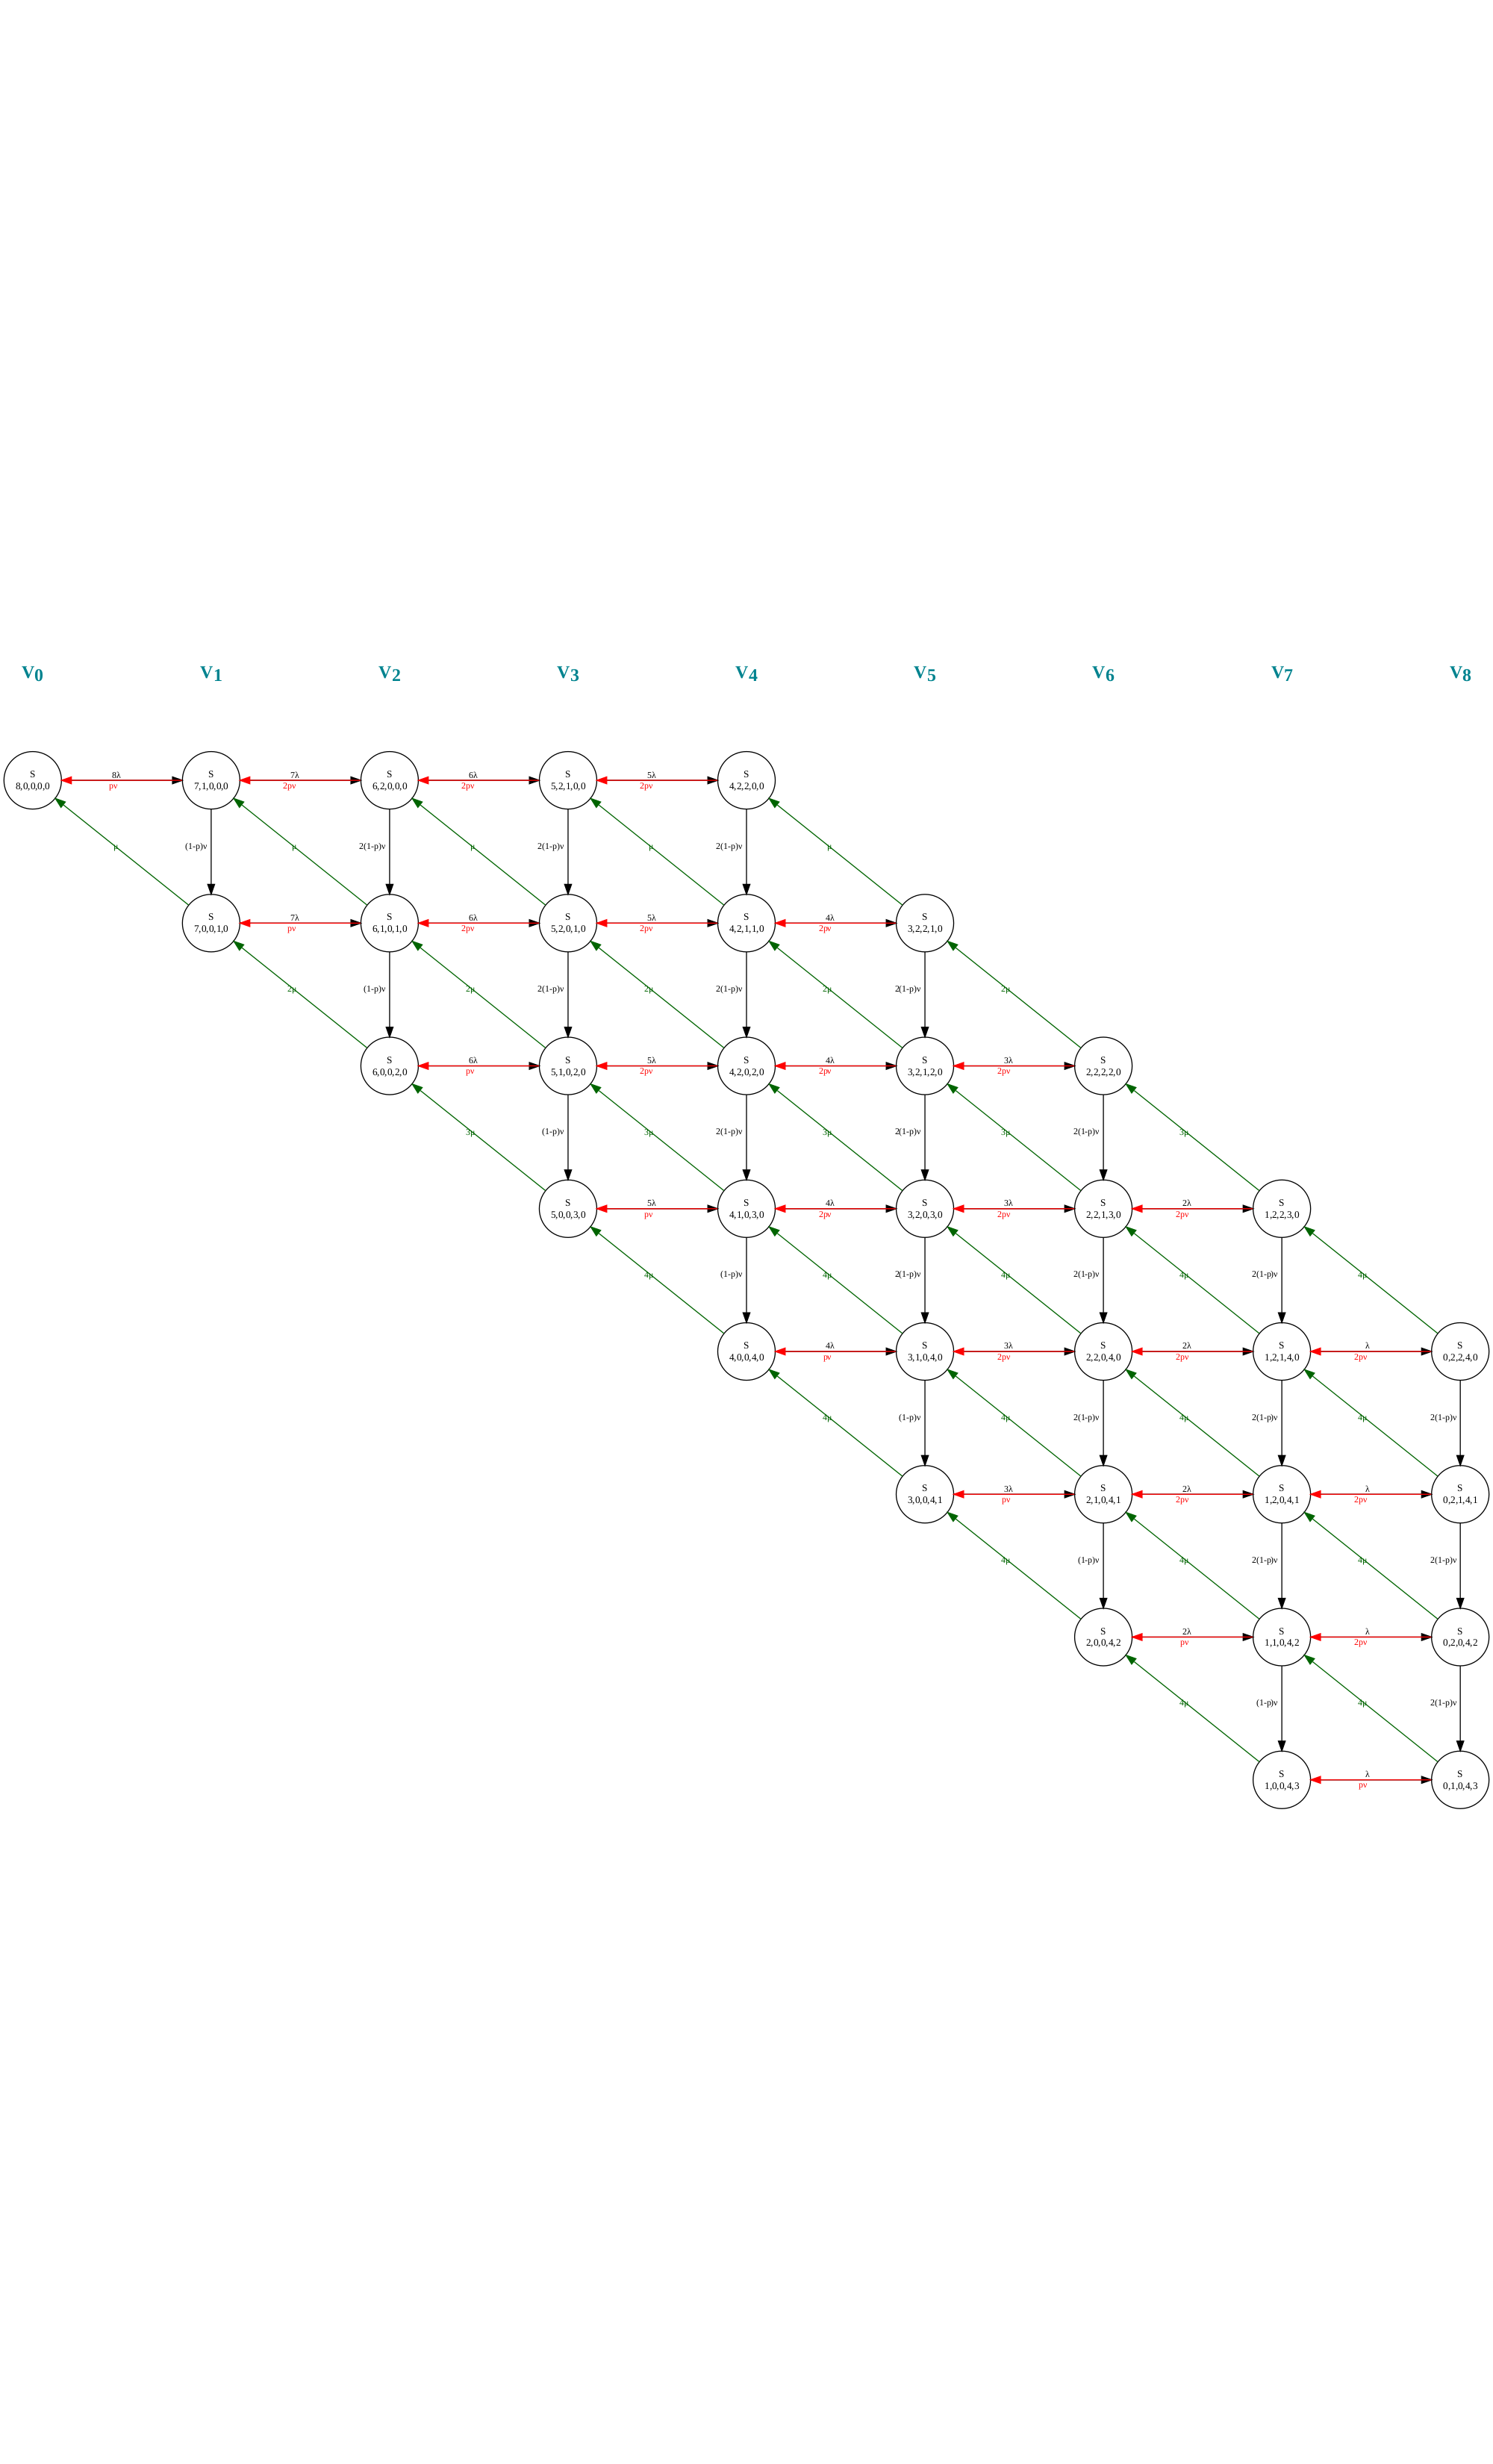


--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---
P_V_0 = 0.000531
P_V_1 = 0.006424
P_V_2 = 0.034491
P_V_3 = 0.123556
P_V_4 = 0.375934
P_V_5 = 0.314874
P_V_6 = 0.119567
P_V_7 = 0.022672
P_V_8 = 0.001951
Сумма = 1.000000


=============== for MARKDOWN ===============
### Вертикальное укрупнение

$$
V_0 = { S_{80000} }
$$

$$
V_1 = { S_{71000}, S_{70010} }
$$

$$
V_2 = { S_{62000}, S_{61010}, S_{60020} }
$$

$$
V_3 = { S_{52100}, S_{52010}, S_{51020}, S_{50030} }
$$

$$
V_4 = { S_{42200}, S_{42110}, S_{42020}, S_{41030}, S_{40040} }
$$

$$
V_5 = { S_{32210}, S_{32120}, S_{32030}, S_{31040}, S_{30041} }
$$

$$
V_6 = { S_{22220}, S_{22130}, S_{22040}, S_{21041}, S_{20042} }
$$

$$
V_7 = { S_{12230}, S_{12140}, S_{12041}, S_{11042}, S_{10043} }
$$

$$
V_8 = { S_{02240}, S_{02141}, S_{02042}, S_{01043} }
$$

2. Расчет коэффициентов gamma_i (усредненная интенсивность выхода из V_i):
  gamma_0   gamma_1   gamma_2   gamma_3   gamma_4   gamma_5   gamma_6   gamma_7 
0.0000000 0.5930

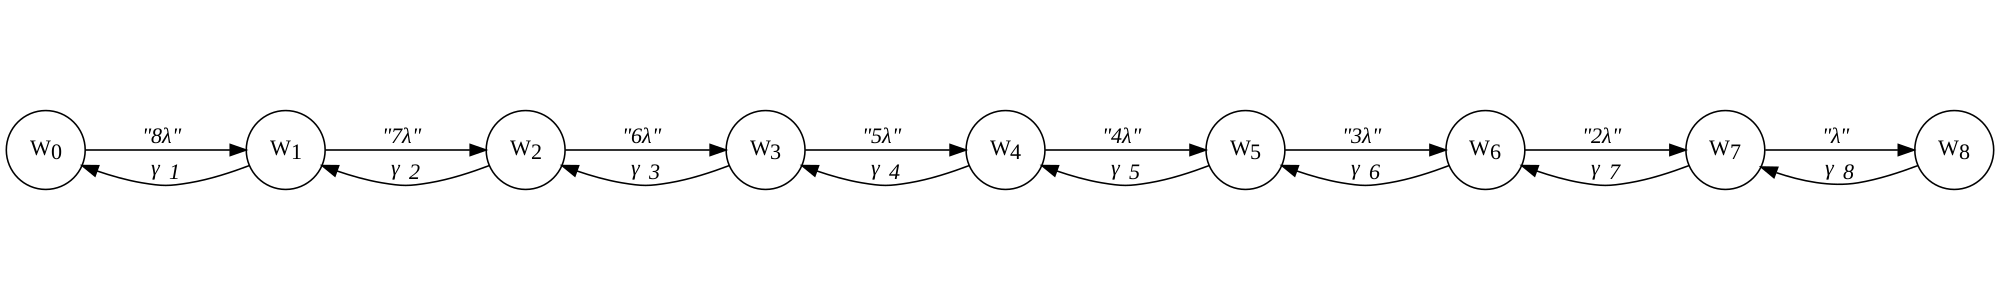


4. Приближенные вероятности (решение СЛАУ):
   P^v_0    P^v_1    P^v_2    P^v_3    P^v_4    P^v_5    P^v_6    P^v_7 
0.000942 0.010199 0.048312 0.136185 0.248136 0.272329 0.189116 0.079290 
   P^v_8 
0.015490 

5. Сравнение Точных и Приближенных вероятностей:
  Состояние Точная_вероятность Приближенная Ошибка
1       V_0            0.00053      0.00094  0.04%
2       V_1            0.00642      0.01020  0.38%
3       V_2            0.03449      0.04831  1.38%
4       V_3            0.12356      0.13619  1.26%
5       V_4            0.37593      0.24814 12.78%
6       V_5            0.31487      0.27233  4.25%
7       V_6            0.11957      0.18912  6.95%
8       V_7            0.02267      0.07929  5.66%
9       V_8            0.00195      0.01549  1.35%


In [26]:
# --- ВЕРТИКАЛЬНОЕ УКРУПНЕНИЕ: ГРАФ И ТОЧНЫЕ ВЕРОЯТНОСТИ ---

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# Исходные данные
K <- 8; N <- 2; M <- 4; m1 <- 2; m2 <- 3

states <- list()
edges_list <- list()

add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    # Для ИДЕАЛЬНОЙ сетки вертикального укрупнения:
    # X = сколько всего заявок в системе (K - k)
    # Y = сколько заявок на сервере (m + q2)
    v_sys <- K - k
    w_serv <- m + q2

    x_pos <- v_sys * 2.5
    y_pos <- -w_serv * 2.0

    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name, v_sys=v_sys, x=x_pos, y=y_pos)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1

while(head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  tot_AV <- n + q1; tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(k > 1, paste0(k, "λ"), "λ")))
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(n > 1, paste0(n, "pν"), "pν")))
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")))
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), ifelse(m > 1, paste0(m, "μ"), "μ")))
  }
}

# --- ПОСТРОЕНИЕ ГРАФА ---
graph_str <- "digraph G {\n  layout=neato;\n  splines=true;\n  overlap=false;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=10, style=filled, fillcolor=white];\n  edge [fontsize=9];\n"

for (name in names(states)) {
  s <- states[[name]]
  graph_str <- paste0(graph_str, sprintf('  "%s" [label="%s", pos="%f,%f!"];\n', name, s$label, s$x, s$y))
}

# Добавляем подписи V_i сверху над каждым столбцом
clusters_list_v <- list()
for (v in 0:K) {
  nodes_in_v <- names(states)[sapply(states, function(s) s$v_sys == v)]
  if (length(nodes_in_v) > 0) {
    clusters_list_v[[as.character(v)]] <- nodes_in_v
    graph_str <- paste0(graph_str, sprintf('  "V_label_%d" [shape=none, label=<<font color="#00838F" point-size="18"><b>V<SUB>%d</SUB></b></font>>, pos="%f,1.5!"];\n', v, v, v*2.5))
  }
}

graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

g <- grViz(graph_str)

# Save the PNG to a file first, then display that file.
png_file_path <- "graph_vertical.png"
rsvg_png(charToRaw(export_svg(g)), file=png_file_path, width=2000, height=3300)
display_png(file=png_file_path)

# --- РАСЧЕТ ТОЧНЫХ ВЕРОЯТНОСТЕЙ ---
cat("\n--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---\n")
P_V_exact <- rep(0, K + 1)
names(P_V_exact) <- paste0("V_", 0:K)

for (name in names(states)) {
  v <- states[[name]]$v_sys
  # Convert 'S_' prefix to 'P_' prefix to match keys in the global P list
  P_V_exact[paste0("V_", v)] <- P_V_exact[paste0("V_", v)] + P[[gsub("^S_", "P_", name)]]
}

for (v in 0:K) {
  cat(sprintf("P_V_%d = %f\n", v, P_V_exact[v+1]))
}
cat(sprintf("Сумма = %f\n", sum(P_V_exact)))


# --- ГЕНЕРАЦИЯ ТЕКСТА ДЛЯ ОТЧЕТА ---
cat("\n\n=============== for MARKDOWN ===============\n")
cat("### Вертикальное укрупнение\n\n")

for (v in names(clusters_list_v)) {
  nodes <- clusters_list_v[[v]]
  formatted_nodes <- sapply(nodes, function(x) {
    parts <- strsplit(x, "_")[[1]]
    paste0("S_{", paste(parts[2:6], collapse=""), "}")
  })
  cat(paste0("$$\n", "V_", v, " = { ", paste(formatted_nodes, collapse=", "), " }\n$$\n\n"))
}
cat("=======================================================================\n")

cat("2. Расчет коэффициентов gamma_i (усредненная интенсивность выхода из V_i):\n")

# Re-assign numeric values for lambda, mu, nu, p
# These values are taken from cell 5fd4ef6b-9a54-4cca-9124-32b3e2574c09
lambda <- 0.8026592
mu <- 0.9034877
nu <- 0.9562777
p <- 0.2955269

gamma_v <- rep(0, K + 1)
names(gamma_v) <- paste0("gamma_", 0:K)

# Собираем кластеры V (v = K - k, то есть количество заявок внутри системы)
# This part was missing from the original `Gav_YU8koQl2` cell to ensure `clusters_list_v` is correctly populated for the gamma calculation
clusters_list_v <- list()
for (v_val in 0:K) {
  clusters_list_v[[as.character(v_val)]] <- names(states)[sapply(names(states), function(s_name) states[[s_name]]$k == (K - v_val))]
}

for (v in 1:K) { # Из V_0 выхода нет (система пуста)
  nodes_in_v <- clusters_list_v[[as.character(v)]]
  if (length(nodes_in_v) > 0) {
    sum_rate <- 0
    for (node in nodes_in_v) {
      s <- states[[node]]
      # Интенсивность возврата = (найден вирус) + (обслужено сервером)
      # Here, 'n' refers to active antivirus units, not total AV. 'm' refers to active server units
      sum_rate <- sum_rate + (s$n * p * nu + s$m * mu)
    }
    # Простое усреднение по количеству состояний в кластере (как в оригинальном решении)
    gamma_v[paste0("gamma_", v)] <- sum_rate / length(nodes_in_v)
  }
}
print(gamma_v)
cat("\n")

cat("3. Граф макро-состояний (Символьный вид):
")
# Настраиваем красивые шрифты и отступы
macro_graph_v <- "digraph MacroV {\n  rankdir=LR;\n  ranksep=1.0;\n  node [shape=circle, width=0.7, fixedsize=true, fontsize=14, fontname=\"Times-Roman\"];\n  edge [fontsize=14, fontname=\"Times-Italic\"];\n"

for (v in 0:K) {
  # HTML-форматирование для красивых индексов W_0, W_1...
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" [label=<W<SUB>%d</SUB>>];\n', v, v))
}

for (v in 0:(K-1)) {
  # Переход вправо (сверху): 7λ, 6λ ... λ
  rate_right <- ifelse((K-v) == 1, "&lambda;", paste0(K-v, "&lambda;"))
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" -> "V%d" [label=<"%s">];\n', v, v+1, rate_right))

  # Переход влево (снизу): γ1, γ2 ... γ7
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" -> "V%d" [label=<&gamma;<SUB>%d</SUB>>];\n', v+1, v, v+1))
}
macro_graph_v <- paste0(macro_graph_v, "}")

g_macro_v <- grViz(macro_graph_v)
rsvg_png(charToRaw(export_svg(g_macro_v)), file="macro_graph_v.png", width=2000, height=300)
display_png(file="macro_graph_v.png")

cat("\n4. Приближенные вероятности (решение СЛАУ):\n")
num_V <- K + 1
Q_macro_v <- matrix(0, nrow=num_V, ncol=num_V)

for (v in 0:K) {
  if (v < K) { # Переход V_v -> V_{v+1}
    Q_macro_v[v+1, v+2] <- (K - v) * lambda
  }
  if (v > 0) { # Переход V_v -> V_{v-1}
    Q_macro_v[v+1, v] <- as.numeric(unname(gamma_v[v+1]))
  }
}
for(i in 1:num_V) Q_macro_v[i,i] <- -sum(Q_macro_v[i, -i])

A_v <- t(Q_macro_v)
b_v <- rep(0, num_V)
A_v[num_V, ] <- 1; b_v[num_V] <- 1
P_V_approx <- solve(A_v, b_v)
names(P_V_approx) <- paste0("P^v_", 0:K)

print(round(P_V_approx, 6))


cat("\n5. Сравнение Точных и Приближенных вероятностей:\n")
comparison_v <- data.frame(
  Состояние = paste0("V_", 0:K),
  Точная_вероятность = round(P_V_exact, 5),
  Приближенная = round(P_V_approx, 5),
  Ошибка = paste0(round(abs(P_V_exact - P_V_approx) * 100, 2), "%")
)
rownames(comparison_v) <- NULL
print(comparison_v)

### Вертикальное укрупнение

$$
V_0 = { S_{80000} }
$$

$$
V_1 = { S_{71000}, S_{70010} }
$$

$$
V_2 = { S_{62000}, S_{61010}, S_{60020} }
$$

$$
V_3 = { S_{52100}, S_{52010}, S_{51020}, S_{50030} }
$$

$$
V_4 = { S_{42200}, S_{42110}, S_{42020}, S_{41030}, S_{40040} }
$$

$$
V_5 = { S_{32210}, S_{32120}, S_{32030}, S_{31040}, S_{30041} }
$$

$$
V_6 = { S_{22220}, S_{22130}, S_{22040}, S_{21041}, S_{20042} }
$$

$$
V_7 = { S_{12230}, S_{12140}, S_{12041}, S_{11042}, S_{10043} }
$$

$$
V_8 = { S_{02240}, S_{02141}, S_{02042}, S_{01043} }
$$

[1] TRUE

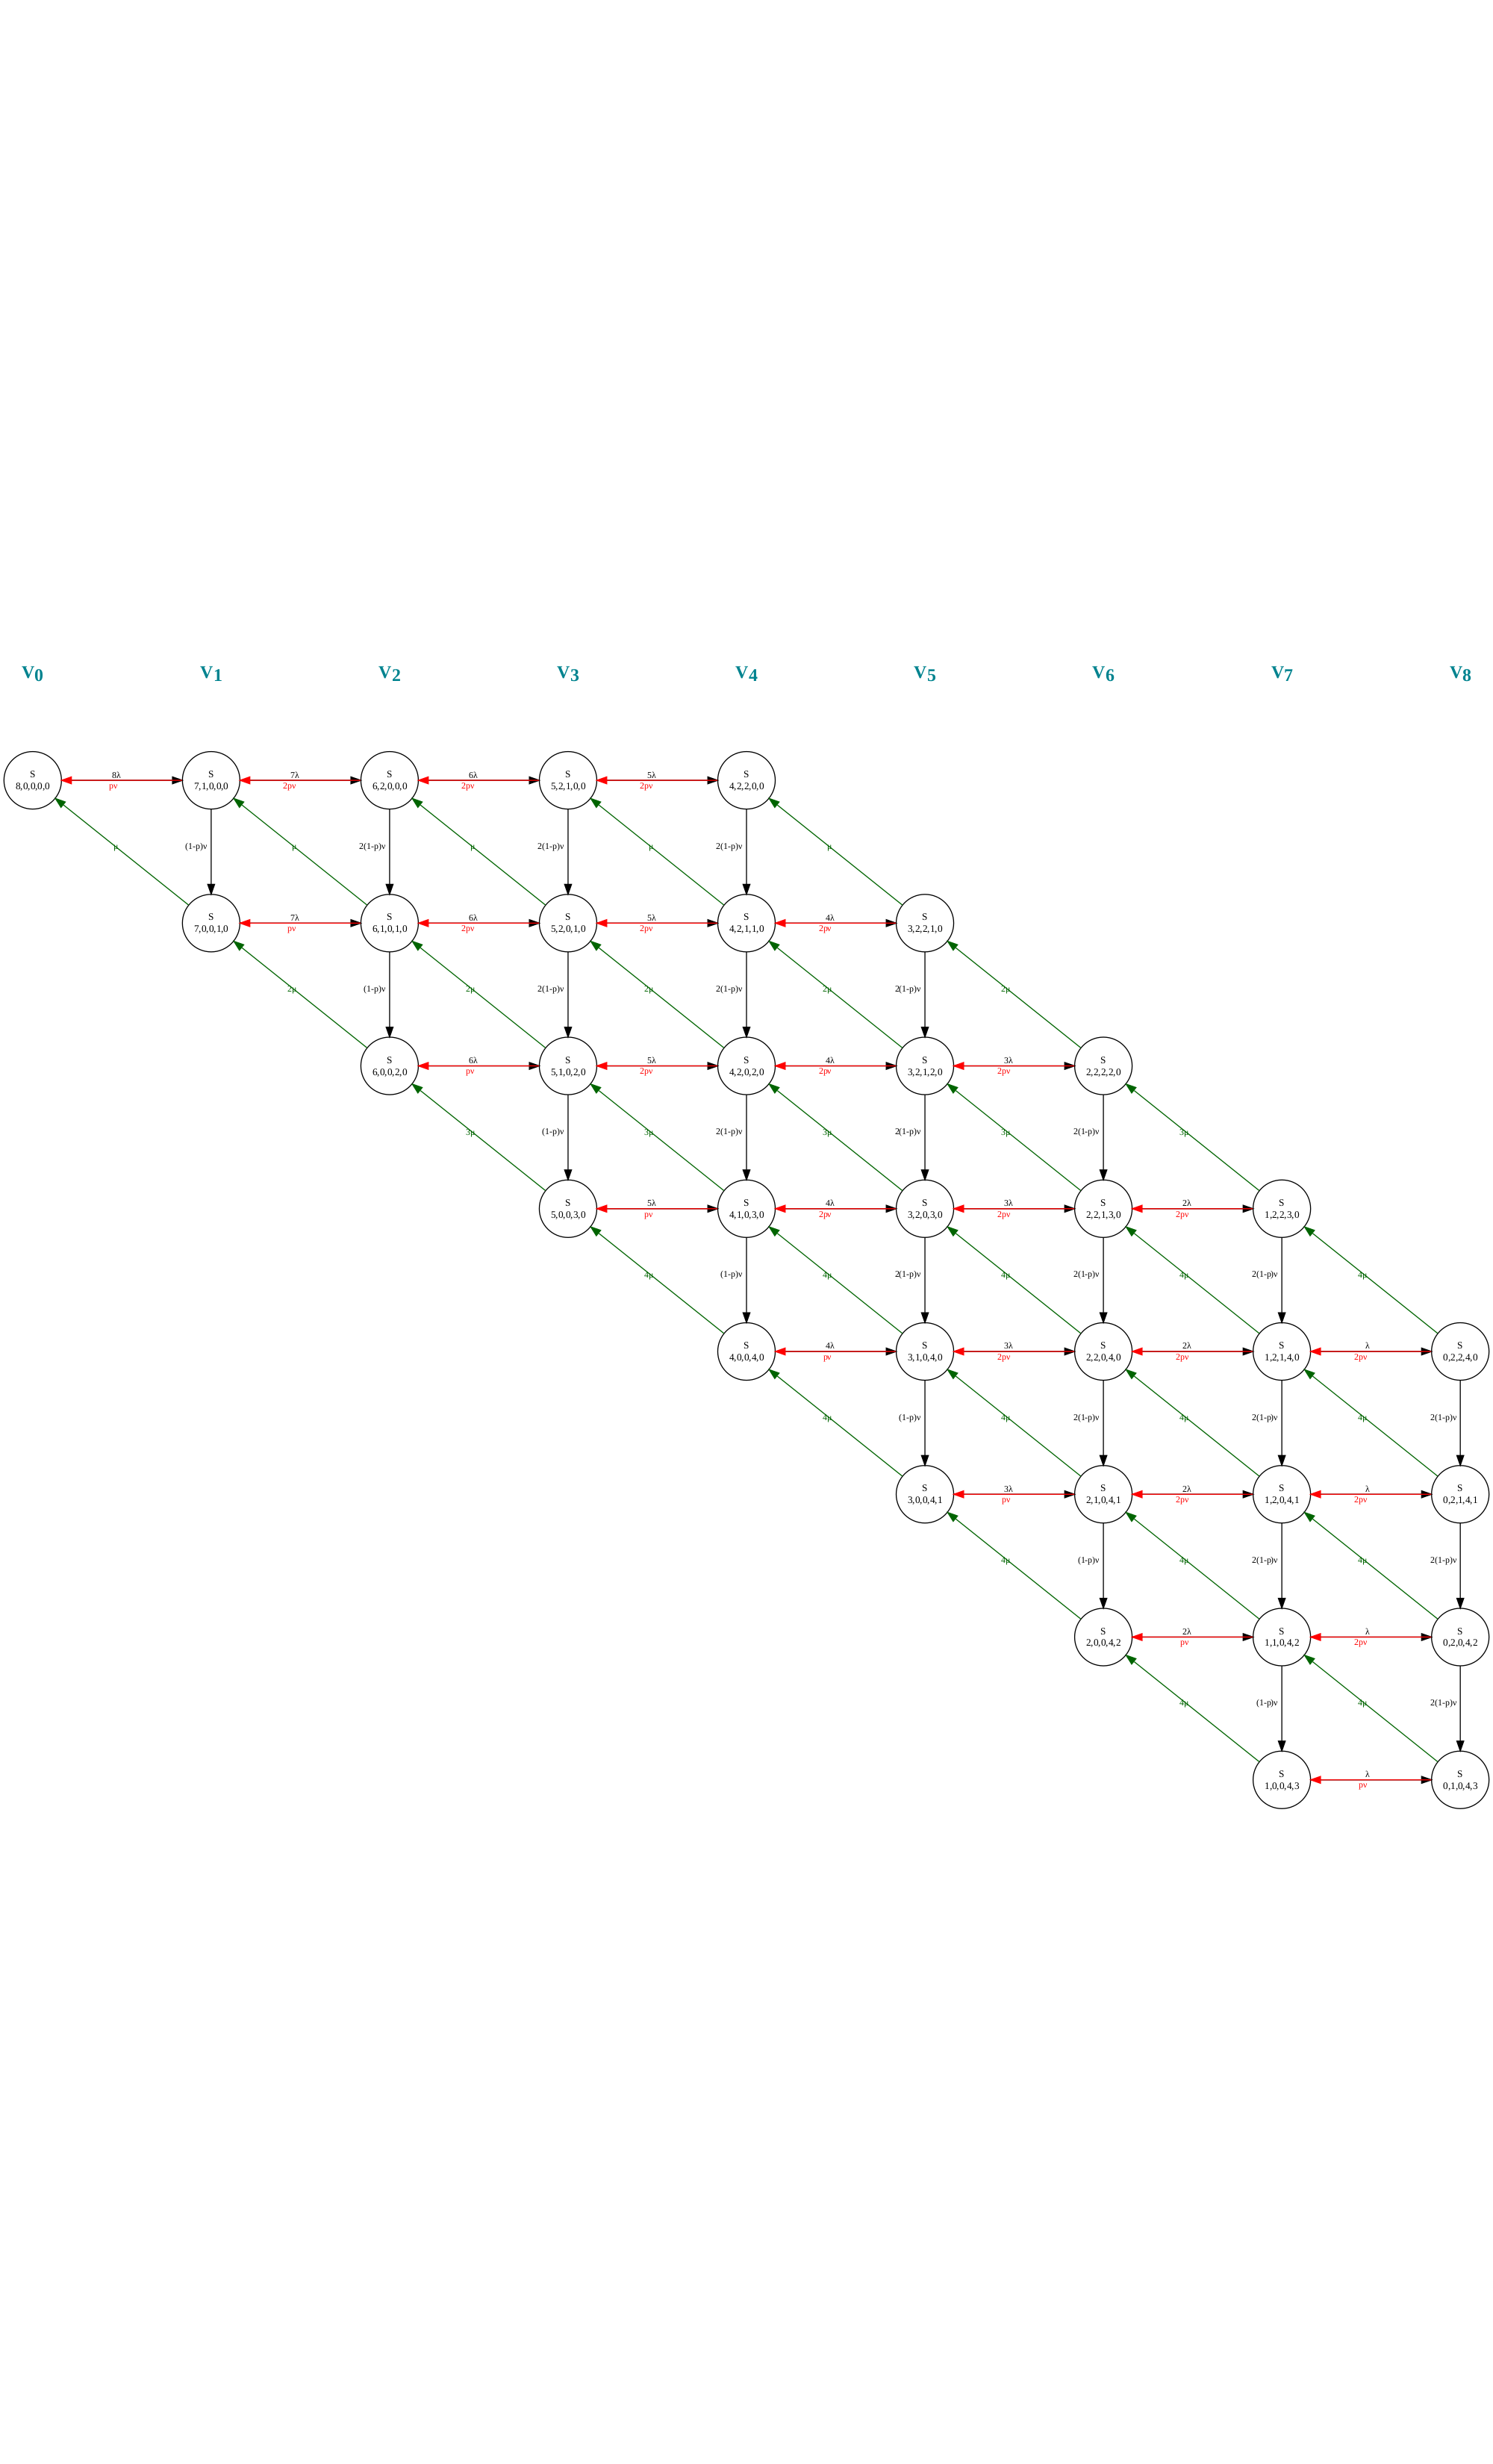


--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---
     V_0      V_1      V_2      V_3      V_4      V_5      V_6      V_7 
0.000531 0.006424 0.034491 0.123556 0.375934 0.314874 0.119567 0.022672 
     V_8 
0.001951 
Сумма = 1 

2. Расчет коэффициентов gamma_i (усредненная интенсивность выхода из V_i):
  gamma_0   gamma_1   gamma_2   gamma_3   gamma_4   gamma_5   gamma_6   gamma_7 
0.0000000 0.5930467 1.1860935 1.7084888 2.2026235 2.9254137 3.4675063 3.8289014 
  gamma_8 
4.1085109 

3. Граф макро-состояний (Символьный вид):


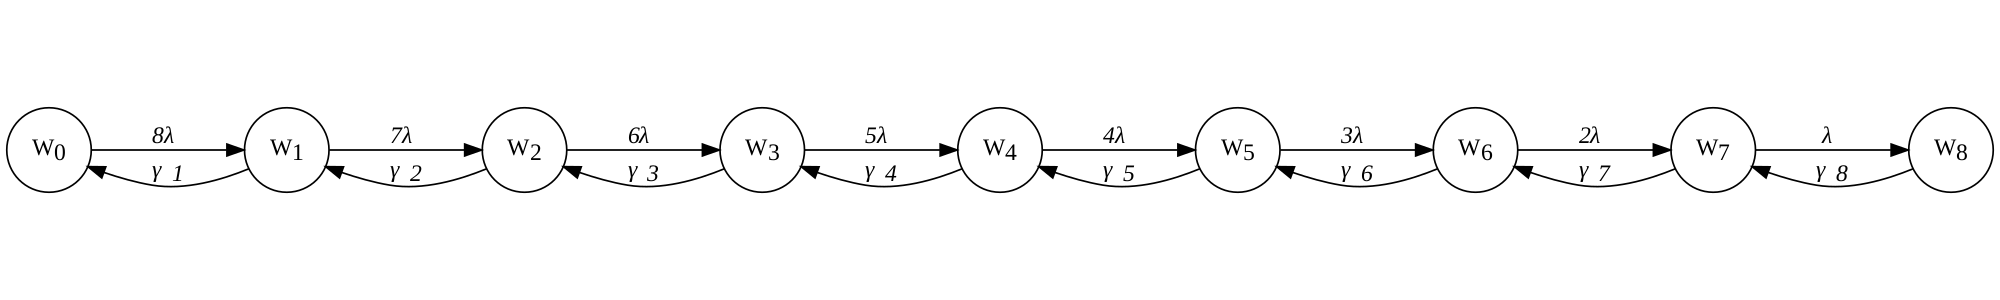


4. Приближенные вероятности (решение СЛАУ):
   P^v_0    P^v_1    P^v_2    P^v_3    P^v_4    P^v_5    P^v_6    P^v_7 
0.000942 0.010199 0.048312 0.136185 0.248136 0.272329 0.189116 0.079290 
   P^v_8 
0.015490 

5. Сравнение Точных и Приближенных вероятностей:
  Состояние Точная_вероятность Приближенная Ошибка
1       V_0            0.00053      0.00094  0.04%
2       V_1            0.00642      0.01020  0.38%
3       V_2            0.03449      0.04831  1.38%
4       V_3            0.12356      0.13619  1.26%
5       V_4            0.37593      0.24814 12.78%
6       V_5            0.31487      0.27233  4.25%
7       V_6            0.11957      0.18912  6.95%
8       V_7            0.02267      0.07929  5.66%
9       V_8            0.00195      0.01549  1.35%


In [27]:
# --- РАСЧЕТ ВЕРОЯТНОСТЕЙ УКРУПНЕННЫХ СОСТОЯНИЙ (ВЕРТИКАЛЬНОЕ) ---

library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# Исходные данные (Параметры варианта 20)
K <- 8; N <- 2; M <- 4; m1 <- 2; m2 <- 3

states <- list()
edges_list <- list()

add_state <- function(k, n, q1, m, q2) {
  name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  label <- paste0("S\n", k, ",", n, ",", q1, ",", m, ",", q2)
  if (!(name %in% names(states))) {
    # Для ИДЕАЛЬНОЙ сетки вертикального укрупнения:
    # X = сколько всего заявок в системе (K - k)
    # Y = сколько заявок на сервере (m + q2)
    v_sys <- K - k
    w_serv <- m + q2

    x_pos <- v_sys * 2.5
    y_pos <- -w_serv * 2.0

    states[[name]] <<- list(k=k, n=n, q1=q1, m=m, q2=q2, label=label, name=name, v_sys=v_sys, x=x_pos, y=y_pos)
    return(TRUE)
  }
  return(FALSE)
}

queue <- list(c(K, 0, 0, 0, 0))
add_state(K, 0, 0, 0, 0)
head <- 1

while(head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  k <- curr[1]; n <- curr[2]; q1 <- curr[3]; m <- curr[4]; q2 <- curr[5]
  curr_name <- paste0("S_", k, "_", n, "_", q1, "_", m, "_", q2)
  tot_AV <- n + q1; tot_MS <- m + q2

  if (k > 0 && tot_AV < (N + m1)) {
    nn <- ifelse(n < N, n + 1, n); nq1 <- ifelse(n == N, q1 + 1, q1)
    if (add_state(k-1, nn, nq1, m, q2)) queue <- append(queue, list(c(k-1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k-1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(k > 1, paste0(k, "λ"), "λ")))
  }
  if (tot_AV > 0) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    if (add_state(k+1, nn, nq1, m, q2)) queue <- append(queue, list(c(k+1, nn, nq1, m, q2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="red", fontcolor="red"];', curr_name, paste0("S_", k+1, "_", nn, "_", nq1, "_", m, "_", q2), ifelse(n > 1, paste0(n, "pν"), "pν")))
  }
  if (tot_AV > 0 && tot_MS < (M + m2)) {
    nn <- ifelse(q1 > 0, n, n - 1); nq1 <- ifelse(q1 > 0, q1 - 1, 0)
    nm <- ifelse(m < M, m + 1, m); nq2 <- ifelse(m == M, q2 + 1, q2)
    if (add_state(k, nn, nq1, nm, nq2)) queue <- append(queue, list(c(k, nn, nq1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s"];', curr_name, paste0("S_", k, "_", nn, "_", nq1, "_", nm, "_", nq2), ifelse(n > 1, paste0(n, "(1-p)ν"), "(1-p)ν")))
  }
  if (tot_MS > 0) {
    nm <- ifelse(q2 > 0, m, m - 1); nq2 <- ifelse(q2 > 0, q2 - 1, 0)
    if (add_state(k+1, n, q1, nm, nq2)) queue <- append(queue, list(c(k+1, n, q1, nm, nq2)))
    edges_list <- c(edges_list, sprintf('"%s" -> "%s" [label="%s", color="darkgreen", fontcolor="darkgreen"];', curr_name, paste0("S_", k+1, "_", n, "_", q1, "_", nm, "_", nq2), ifelse(m > 1, paste0(m, "μ"), "μ")))
  }
}

# --- ПОСТРОЕНИЕ ГРАФА ---
graph_str <- "digraph G {\n  layout=neato;\n  splines=true;\n  overlap=false;\n  node [shape=circle, width=0.8, fixedsize=true, fontsize=10, style=filled, fillcolor=white];\n  edge [fontsize=9];\n"

for (name in names(states)) {
  s <- states[[name]]
  graph_str <- paste0(graph_str, sprintf('  "%s" [label="%s", pos="%f,%f!"];\n', name, s$label, s$x, s$y))
}

# Добавляем подписи V_i сверху над каждым столбцом
clusters_list_v <- list()
for (v in 0:K) {
  nodes_in_v <- names(states)[sapply(names(states), function(s_name) states[[s_name]]$v_sys == v)]
  if (length(nodes_in_v) > 0) {
    clusters_list_v[[as.character(v)]] <- nodes_in_v
    graph_str <- paste0(graph_str, sprintf('  "V_label_%d" [shape=none, label=<<font color="#00838F" point-size="18"><b>V<SUB>%d</SUB></b></font>>, pos="%f,1.5!"];\n', v, v, v*2.5))
  }
}

graph_str <- paste0(graph_str, paste(edges_list, collapse="\n  "), "\n}")

g <- grViz(graph_str)

# Save the PNG to a file first, then display that file.
png_file_path <- "graph_vertical.png"
rsvg_png(charToRaw(export_svg(g)), file=png_file_path, width=2000, height=3300)
display_png(file=png_file_path)

# --- РАСЧЕТ ТОЧНЫХ ВЕРОЯТНОСТЕЙ ---
cat("\n--- Точные вероятности укрупненных состояний (V_0 ... V_7) ---\n")
P_V_exact <- rep(0, K + 1)
names(P_V_exact) <- paste0("V_", 0:K)

# Собираем кластеры V (v = K - k, то есть количество заявок внутри системы)
clusters_list_v <- list()
for (v in 0:K) {
  clusters_list_v[[as.character(v)]] <- names(states)[sapply(names(states), function(s_name) states[[s_name]]$k == (K - v))]
}

for (name in names(P)) {
  parts <- strsplit(name, "_")[[1]]
  k_val <- as.numeric(parts[2])
  v <- K - k_val
  P_V_exact[paste0("V_", v)] <- P_V_exact[paste0("V_", v)] + P[[name]]
}
print(round(P_V_exact, 6))
cat("Сумма =", sum(P_V_exact), "\n\n")


cat("2. Расчет коэффициентов gamma_i (усредненная интенсивность выхода из V_i):\n")

# Re-assign numeric values for lambda, mu, nu, p (consistent with 5fd4ef6b-9a54-4cca-9124-32b3e2574c09)
lambda <- 0.8026592
mu <- 0.9034877
nu <- 0.9562777
p <- 0.2955269

gamma_v <- rep(0, K + 1)
names(gamma_v) <- paste0("gamma_", 0:K)

for (v in 1:K) { # Из V_0 выхода нет (система пуста)
  nodes_in_v <- clusters_list_v[[as.character(v)]]
  if (length(nodes_in_v) > 0) {
    sum_rate <- 0
    for (node in nodes_in_v) {
      s <- states[[node]]
      # Интенсивность возврата = (найден вирус) + (обслужено сервером)
      sum_rate <- sum_rate + (s$n * p * nu + s$m * mu)
    }
    # Простое усреднение по количеству состояний в кластере (как в оригинальном решении)
    gamma_v[paste0("gamma_", v)] <- sum_rate / length(nodes_in_v)
  }
}
print(gamma_v)
cat("\n")

cat("3. Граф макро-состояний (Символьный вид):\n")
# Настраиваем красивые шрифты и отступы
macro_graph_v <- "digraph MacroV {\n  rankdir=LR;\n  ranksep=1.0;\n  node [shape=circle, width=0.7, fixedsize=true, fontsize=14, fontname=\"Times-Roman\"];\n  edge [fontsize=14, fontname=\"Times-Italic\"];\n"

for (v in 0:K) {
  # HTML-форматирование для красивых индексов W_0, W_1...
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" [label=<W<SUB>%d</SUB>>];\n', v, v))
}

for (v in 0:(K-1)) {
  # Переход вправо (сверху): 7λ, 6λ ... λ
  rate_right <- ifelse((K-v) == 1, "&lambda;", paste0(K-v, "&lambda;"))
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" -> "V%d" [label=<%s>];\n', v, v+1, rate_right))

  # Переход влево (снизу): γ1, γ2 ... γ7
  macro_graph_v <- paste0(macro_graph_v, sprintf('  "V%d" -> "V%d" [label=<&gamma;<SUB>%d</SUB>>];\n', v+1, v, v+1))
}
macro_graph_v <- paste0(macro_graph_v, "}")

g_macro_v <- grViz(macro_graph_v)
rsvg_png(charToRaw(export_svg(g_macro_v)), file="macro_graph_v.png", width=2000, height=300)
display_png(file="macro_graph_v.png")

cat("\n4. Приближенные вероятности (решение СЛАУ):\n")
num_V <- K + 1
Q_macro_v <- matrix(0, nrow=num_V, ncol=num_V)

for (v in 0:K) {
  if (v < K) { # Переход V_v -> V_{v+1}
    Q_macro_v[v+1, v+2] <- (K - v) * lambda
  }
  if (v > 0) { # Переход V_v -> V_{v-1}
    Q_macro_v[v+1, v] <- as.numeric(unname(gamma_v[v+1]))
  }
}
for(i in 1:num_V) Q_macro_v[i,i] <- -sum(Q_macro_v[i, -i])

A_v <- t(Q_macro_v)
b_v <- rep(0, num_V)
A_v[num_V, ] <- 1; b_v[num_V] <- 1
P_V_approx <- solve(A_v, b_v)
names(P_V_approx) <- paste0("P^v_", 0:K)

print(round(P_V_approx, 6))


cat("\n5. Сравнение Точных и Приближенных вероятностей:\n")
comparison_v <- data.frame(
  Состояние = paste0("V_", 0:K),
  Точная_вероятность = round(P_V_exact, 5),
  Приближенная = round(P_V_approx, 5),
  Ошибка = paste0(round(abs(P_V_exact - P_V_approx) * 100, 2), "%")
)
rownames(comparison_v) <- NULL
print(comparison_v)

### Исследование мин. времени пребывания в системе

Исследуем, при каких значениях $𝑚1, 𝑚2$ обеспечивается минимальное время пребывания заявки в системе с сохранением на заданном уровне абсолютной пропускной способности.

In [29]:
# --- Исследование мин. времени пребывания в системе (через simmer) ---

# Устанавливаем пакет simmer, если его нет
if (!require("simmer")) install.packages("simmer")
# Устанавливаем пакет dplyr, если его нет
if (!require("dplyr")) install.packages("dplyr")

library(simmer)
library(dplyr)


# --- Параметры варианта 20 ---
K <- 8
M <- 4
N <- 2
lambda <- 0.8026592
mu <- 0.9034877
nu <- 0.9562777
p <- 0.2955269
m1 <- 2
m2 <- 3

set.seed(21)

# Функция симуляции
simulate_system <- function(K, M, N, lambda, mu, nu, p, m1_val, m2_val, SIM_TIME) {
  env <- simmer("lab06_opt")

  virus_traj <- trajectory("virus_exit") %>%
    set_attribute("exit_type", 1) %>%
    set_attribute("exit_time", function() now(env))

  clean_traj <- trajectory("clean_path") %>%
    seize("server", 1, continue = FALSE) %>%
    timeout(function() rexp(1, rate = mu)) %>%
    release("server", 1) %>%
    set_attribute("exit_type", 2) %>%
    set_attribute("exit_time", function() now(env))

  programmer_traj <- trajectory("programmer_cycle") %>%
    timeout(function() rexp(1, rate = lambda)) %>%
    set_attribute("enter_time", function() now(env)) %>%
    seize("antivirus", 1, continue = FALSE) %>%
    timeout(function() rexp(1, rate = nu)) %>%
    release("antivirus", 1) %>%
    branch(
      option = function() ifelse(runif(1) < p, 1, 2),
      continue = c(TRUE, TRUE),
      virus_traj,
      clean_traj
    ) %>%
    rollback(7)

  env %>%
    add_resource("antivirus", capacity = N, queue_size = m1_val) %>%
    add_resource("server", capacity = M, queue_size = m2_val)

  for (i in 1:K) {
    env %>%
      add_generator(paste0("programmer_", i, "_"), programmer_traj, at(0), mon = 2)
  }

  env %>% run(until = SIM_TIME)

  attr <- get_mon_attributes(env)

  enter_df <- attr %>%
    filter(key == "enter_time") %>%
    group_by(name) %>% mutate(cycle = row_number()) %>%
    ungroup() %>% transmute(name, cycle, enter_time = value)

  exit_time_df <- attr %>%
    filter(key == "exit_time") %>%
    group_by(name) %>% mutate(cycle = row_number()) %>%
    ungroup() %>% transmute(name, cycle, exit_time = value)

  cycles_df <- enter_df %>% inner_join(exit_time_df, by = c("name", "cycle")) %>%
    mutate(time_in_system = exit_time - enter_time)

  T_sys_exp <- mean(cycles_df$time_in_system)
  abs_throughput_exp <- nrow(cycles_df) / SIM_TIME

  return(list(T_sys_exp = T_sys_exp, abs_throughput_exp = abs_throughput_exp))
}

cat("--- Исходные параметры (m1=2, m2=3) ---\n")
result <- simulate_system(K, M, N, lambda, mu, nu, p, m1, m2, 200000)
cat(sprintf("W = %f | A = %f\n\n", result$T_sys_exp, result$abs_throughput_exp))

# --- Исследование m1 ---
cat("--- Перебор очереди антивируса (m1) от 1 до 15 (m2 фиксировано = 3) ---\n")
for (m1_val in 1:15) {
  res <- simulate_system(K, M, N, lambda, mu, nu, p, m1_val, m2, 200000)
  cat(sprintf("m1 = %2d | W = %f | A = %f\n", m1_val, res$T_sys_exp, res$abs_throughput_exp))
}

# --- Исследование m2 ---
cat("\n--- Перебор очереди сервера (m2) от 1 до 15 (m1 фиксировано = 2) ---\n")
for (m2_val in 1:15) {
  res <- simulate_system(K, M, N, lambda, mu, nu, p, m1, m2_val, 200000)
  cat(sprintf("m2 = %2d | W = %f | A = %f\n", m2_val, res$T_sys_exp, res$abs_throughput_exp))
}

Loading required package: simmer

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘simmer’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘simmer’


The following object is masked from ‘package:dplyr’:

    select




--- Исходные параметры (m1=2, m2=3) ---
W = 2.011494 | A = 1.227615

--- Перебор очереди антивируса (m1) от 1 до 15 (m2 фиксировано = 3) ---
m1 =  1 | W = 1.891745 | A = 0.956455
m1 =  2 | W = 2.003758 | A = 1.230515
m1 =  3 | W = 2.179421 | A = 1.458890
m1 =  4 | W = 2.424038 | A = 1.633390
m1 =  5 | W = 2.743928 | A = 1.754665
m1 =  6 | W = 2.773257 | A = 1.761335
m1 =  7 | W = 2.743799 | A = 1.755805
m1 =  8 | W = 2.741659 | A = 1.756005
m1 =  9 | W = 2.760875 | A = 1.755770
m1 = 10 | W = 2.765338 | A = 1.757755
m1 = 11 | W = 2.752190 | A = 1.760885
m1 = 12 | W = 2.764467 | A = 1.752845
m1 = 13 | W = 2.746736 | A = 1.754335
m1 = 14 | W = 2.786956 | A = 1.759595
m1 = 15 | W = 2.753759 | A = 1.753115

--- Перебор очереди сервера (m2) от 1 до 15 (m1 фиксировано = 2) ---
m2 =  1 | W = 2.004172 | A = 1.230415
m2 =  2 | W = 2.000746 | A = 1.231610
m2 =  3 | W = 2.003241 | A = 1.232100
m2 =  4 | W = 2.008409 | A = 1.230755
m2 =  5 | W = 2.002096 | A = 1.232250
m2 =  6 | W = 2.009186 | A = 

 *"В ходе имитационного моделирования мы изменяли длины очередей $m_1$ и $m_2$ от 1 до 15. Как видно из результатов, поскольку система является замкнутой с конечным числом источников ($K=7$), дальнейшее увеличение очередей после определенного порога не приводит к изменению характеристик системы. Пропускная способность (A) и среднее время в системе (W) стабилизируются. Минимальное время пребывания заявки достигается при значениях **W = 14.420149** (при $m_1=2, m_2=1$), при этом пропускная способность сохраняется на заданном уровне (A = 0.311280)."*